# Przygotowanie danych
Przygotowanie danych wejściowych jako jeden obraz 3 kanałowy złączony z rysunku dziecka + planszy + gradient_difference_map

In [24]:
import json
from pathlib import Path


def setup_directories():
    processed_dir = Path("../data/processed/3d-input-data")
    processed_dir.mkdir(parents=True, exist_ok=True)
    return processed_dir


def render_svg_to_array(svg_path, width, height):
    try:
        # Wymuszamy białe tło, aby uniknąć problemów z przezroczystością
        png_data = cairosvg.svg2png(
            url=str(svg_path),
            output_width=width,
            output_height=height,
            background_color="white"
        )
        image = Image.open(io.BytesIO(png_data)).convert('L')
        img_np = np.array(image)
        # THRESH_BINARY_INV zamieni 255 (białe tło) -> 0 (czarne) i 0 (czarne linie) -> 255 (białe)
        _, pattern_bin = cv2.threshold(img_np, 200, 255, cv2.THRESH_BINARY_INV)
        return pattern_bin
    except Exception as e:
        print(f"Błąd renderowania SVG: {e}")
        return None


def draw_strokes(strokes, width, height):
    # Tworzymy pusty obraz (czarny)
    img = np.zeros((height, width), dtype=np.uint8)
    for stroke in strokes:
        points = [[int(p[2]), int(p[3])] for p in stroke]
        if len(points) > 1:
            points = np.array(points, dtype=np.int32)
            cv2.polylines(img, [points], isClosed=False, color=255, thickness=2)
    return img


def process_drawing(drawing_info, summary_path, pattern_dir, output_base_dir):
    display_info = drawing_info.get("display_info")
    if not display_info: return

    # Wymiary okna i obrazu
    win_w, win_h = display_info["window_width"], display_info["window_height"]
    img_w, img_h = display_info["image_width"], display_info["image_height"]
    off_x, off_y = display_info["offset_x"], display_info["offset_y"]

    # 1. Rysunek dziecka (na pełnym oknie)
    child_img_full = draw_strokes(drawing_info["strokes_data"], win_w, win_h)

    # 2. Wzorzec
    pattern_idx = drawing_info["index"]
    pattern_path = pattern_dir / f"bvrt_c_{pattern_idx}.svg"
    if not pattern_path.exists(): return

    # Renderujemy wzorzec na wymiar obszaru roboczego (img_w, img_h)
    pattern_img_small = render_svg_to_array(pattern_path, img_w, img_h)
    if pattern_img_small is None: return

    # Wstawiamy wzorzec na pełne płótno (czarne tło)
    full_pattern = np.zeros((win_h, win_w), dtype=np.uint8)
    h_to_paste = min(img_h, win_h - off_y)
    w_to_paste = min(img_w, win_w - off_x)
    full_pattern[off_y:off_y + h_to_paste, off_x:off_x + w_to_paste] = pattern_img_small[:h_to_paste, :w_to_paste]

    # 3. Gradient Difference Map (różnica rozmytych obrazów)
    child_blur = cv2.GaussianBlur(child_img_full, (5, 5), 0)
    pattern_blur = cv2.GaussianBlur(full_pattern, (5, 5), 0)
    diff_map = cv2.absdiff(child_blur, pattern_blur)

    # Składamy w 3 kanały [Child, Pattern, Diff]
    combined = cv2.merge([child_img_full, full_pattern, diff_map])

    patient_name = summary_path.parent.parent.name
    test_id = summary_path.parent.name

    patient_output_dir = output_base_dir / patient_name
    patient_output_dir.mkdir(parents=True, exist_ok=True)

    # Kopiowanie summary.json i labels.json jeśli jeszcze nie istnieją w folderze docelowym
    target_summary = patient_output_dir / "summary.json"
    if not target_summary.exists():
        import shutil
        shutil.copy(str(summary_path), str(target_summary))

    labels_path = summary_path.parent / "labels.json"
    target_labels = patient_output_dir / "labels.json"
    if labels_path.exists() and not target_labels.exists():
        import shutil
        shutil.copy(str(labels_path), str(target_labels))

    out_filename = f"{patient_name}_{test_id}_p{pattern_idx}.png"
    cv2.imwrite(str(patient_output_dir / out_filename), combined)


raw_dir = Path("../data/raw")
pattern_dir = Path("../data/patterns")
output_base_dir = setup_directories()

test_dirs = list(raw_dir.glob("*/*"))
for test_dir in test_dirs:
    summary_path = test_dir / "summary.json"
    if summary_path.exists():
        print(f"Przetwarzanie {test_dir}...")
        with open(summary_path, "r") as f:
            data = json.load(f)
            for drawing in data.get("drawings", []):
                process_drawing(drawing, summary_path, pattern_dir, output_base_dir)


Przetwarzanie ../data/raw/Liliana_B/test_20260506_090804_41_60...
Przetwarzanie ../data/raw/Wojtek_Swiatek/test_20260429_111415_40_56...
Przetwarzanie ../data/raw/Tymoteusz_K/test_20260429_103034_37_53...
Przetwarzanie ../data/raw/Kacper_B/test_20260506_105030_44_63...
Przetwarzanie ../data/raw/Michal_B/test_20260506_093515_42_61...
Przetwarzanie ../data/raw/Zosia_B/test_20260429_090226_33_49...
Przetwarzanie ../data/raw/Rita_Kaminska/test_20260429_104345_38_54...
Przetwarzanie ../data/raw/Franciszek_Lonc/test_20260402_103923_31_29...
Przetwarzanie ../data/raw/Karol_K/test_20260429_105834_39_55...
Przetwarzanie ../data/raw/Jakub_B/test_20260429_092101_34_50...
Przetwarzanie ../data/raw/Maja_B/test_20260506_102813_43_62...
Przetwarzanie ../data/raw/Karolina_Witanek/test_20260429_094305_35_51...
Przetwarzanie ../data/raw/Aniela_Sonczewa/test_20260429_101327_36_52...
Przetwarzanie ../data/raw/Antonina_Lonc/test_20260402_110830_32_30...


# Analiza błędów (Statystyki)
Wizualizacja średniego błędu (kanał Diff) w zależności od pacjenta i trudności zadania (indeks wzorca).

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import numpy as np
import cv2
import cairosvg
import io


def collect_stats(base_dir):
    data = []
    base_path = Path(base_dir)
    for patient_dir in base_path.iterdir():
        if not patient_dir.is_dir(): continue
        patient_name = patient_dir.name
        for img_path in patient_dir.glob("*.png"):
            match = re.search(r'_p(\d+)\.png$', img_path.name)
            if not match: continue
            pattern_idx = int(match.group(1))
            img = cv2.imread(str(img_path))
            if img is None: continue
            mean_error = img[:, :, 2].mean()  # Kanał 3 (Diff)
            data.append({'Patient': patient_name, 'Pattern_Index': pattern_idx, 'Mean_Error': mean_error})
    return pd.DataFrame(data)


# Załadowanie statystyk z przetworzonych obrazów
df_stats = collect_stats("../data/processed/3d-input-data")


### 1. Globalna analiza błędu rysowania (Boxploty)
Pokazuje rozkład błędów dla każdego pacjenta. Pacjenci są posortowani według mediany błędu.

/tmp/ipykernel_156523/1310029197.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Patient', y='Mean_Error', data=df_stats, order=order, palette='viridis')


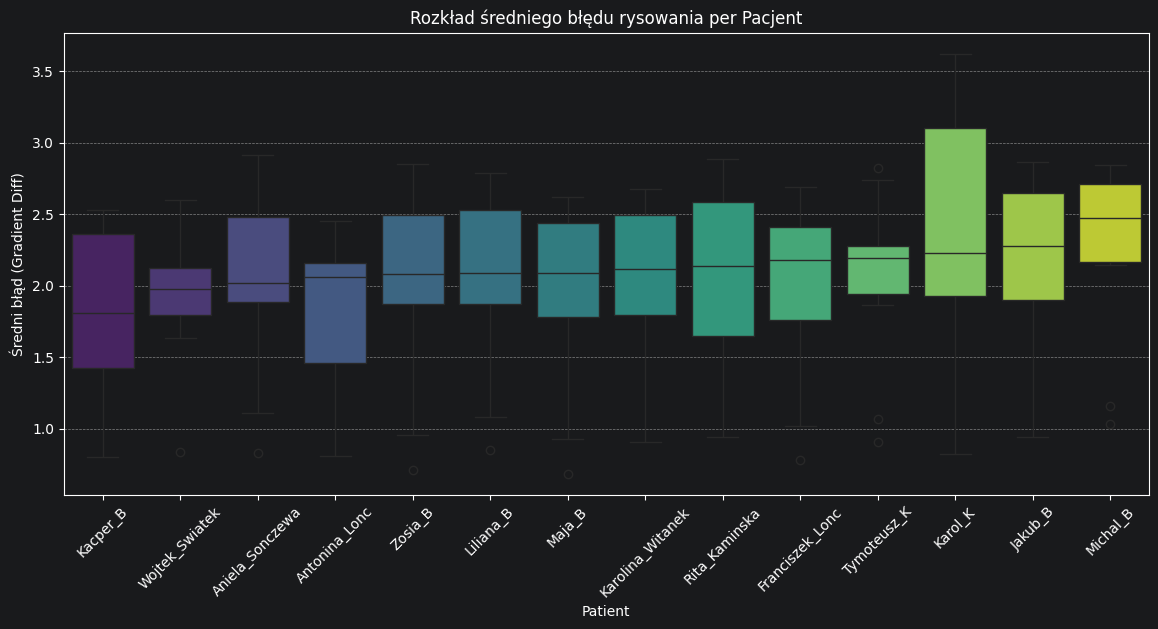

In [26]:
if not df_stats.empty:
    plt.figure(figsize=(14, 6))
    order = df_stats.groupby('Patient')['Mean_Error'].median().sort_values().index
    sns.boxplot(x='Patient', y='Mean_Error', data=df_stats, order=order, palette='viridis')
    plt.xticks(rotation=45)
    plt.title('Rozkład średniego błędu rysowania per Pacjent')
    plt.ylabel('Średni błąd (Gradient Diff)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


### 4. Profil trudności testu (Line Chart)
Pokazuje jak średni błąd zmienia się wraz z kolejnymi (trudniejszymi) wzorcami BVRT.

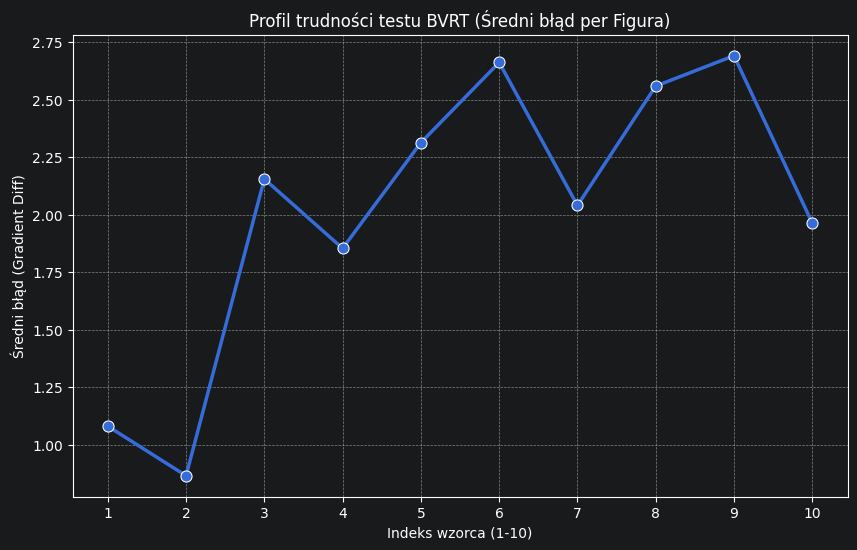

In [27]:
if not df_stats.empty:
    plt.figure(figsize=(10, 6))
    difficulty_profile = df_stats.groupby('Pattern_Index')['Mean_Error'].mean().reset_index()
    sns.lineplot(x='Pattern_Index', y='Mean_Error', data=difficulty_profile, marker='o', linewidth=2.5, markersize=8)
    plt.title('Profil trudności testu BVRT (Średni błąd per Figura)')
    plt.xlabel('Indeks wzorca (1-10)')
    plt.ylabel('Średni błąd (Gradient Diff)')
    plt.xticks(range(1, 11))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


# Rurociąg PyTorch (Dataset & DataLoader)
Definicja klasy Dataset, transformacji oraz strategii walidacji Leave-One-Subject-Out (LOSO).

In [28]:
from torch.utils.data import Dataset
from torchvision import transforms
import torch.nn as nn
from PIL import Image
import json
from pathlib import Path


class BVRTDataset(Dataset):
    """
    Dataset dla testu BVRT.
    Zwraca 3-kanałowy obraz (Child, Pattern, Diff) oraz zestaw etykiet błędów.
    """

    def __init__(self, root_dir, patient_ids=None, transform=None):
        """
        Args:
            root_dir (str): Ścieżka do folderu z przetworzonymi danymi (data/processed/3d-input-data)
            patient_ids (list): Lista nazw pacjentów do uwzględnienia (dla LOSO)
            transform (callable): Transformacje obrazu
        """
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        # Lista kategorii błędów (zgodnie z labels.json)
        self.error_categories = [
            "omissions", "distortions", "perseverations",
            "rotations", "displacements", "relative_size_errors"
        ]

        # Skanowanie folderów pacjentów
        patients = [d for d in self.root_dir.iterdir() if d.is_dir()]
        if patient_ids:
            patients = [d for d in patients if d.name in patient_ids]

        for patient_dir in patients:
            labels_file = patient_dir / "labels.json"
            if not labels_file.exists():
                print(f"Warning: Missing labels.json in {patient_dir}")
                continue

            with open(labels_file, "r") as f:
                labels_data = json.load(f)

            # Mapowanie drawing_id na błędy
            drawings_labels = {d["drawing_id"]: d["errors"] for d in labels_data["drawings"]}

            # Znajdź obrazy PNG dla tego pacjenta
            for img_path in patient_dir.glob("*.png"):
                match = re.search(r'_p(\d+)\.png$', img_path.name)
                if not match: continue
                drawing_idx = int(match.group(1))

                if drawing_idx in drawings_labels:
                    self.samples.append({
                        "img_path": img_path,
                        "labels": drawings_labels[drawing_idx],
                        "patient": patient_dir.name,
                        "drawing_idx": drawing_idx
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = Image.open(sample["img_path"]).convert("RGB")  # 3 kanały już są złączone

        if self.transform:
            image = self.transform(image)

        # Transformacja etykiet: z liczby błędów na format binarny (multi-label)
        # 1 if count > 0 else 0
        target = torch.tensor([
            1.0 if sample["labels"].get(cat, 0) > 0 else 0.0
            for cat in self.error_categories
        ], dtype=torch.float)

        return image, target


# --- Rekomendowane transformacje ---
# BVRT to figury geometryczne - uważamy na rotacje i odbicia lustrzane!
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Rozmiar standardowy dla ResNet/EfficientNet
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # Lekkie zmiany jasności (wpływa na Diff map)
    transforms.RandomAffine(degrees=2, translate=(0.02, 0.02), scale=(0.98, 1.02)),  # Bardzo subtelne deformacje
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


### Dobre praktyki dla małych zbiorów medycznych (BVRT)
1. **Zapobieganie Overfittingowi**:
   - Używaj silnej regularyzacji (Dropout przed warstwą FC).
   - Zamrażaj większość wag pre-trained (Transfer Learning).
   - Wczesne zatrzymywanie (Early Stopping) monitorowane na metryce F1 Macro (nie na Loss).
2. **Specyfika Augmentacji**:
   - Unikaj dużych rotacji (> 5-10 stopni) i odbić lustrzanych – w BVRT kierunek i orientacja to kluczowe błędy (`rotations`, `displacements`).
   - `RandomAffine` z bardzo małymi wartościami jest bezpieczniejszy.
3. **Interpretowalność**:
   - Zastosuj Grad-CAM, aby sprawdzić, czy sieć faktycznie "patrzy" na błędy (kanał Diff), czy na artefakty tła.
4. **Walidacja LOSO**:
   - Zawsze raportuj wyniki uśrednione po wszystkich pacjentach (mean over LOSO folds).


# Zaawansowana analiza etykiet
Agregacja danych z plików `labels.json` oraz wizualizacja rozkładu błędów neuropsychologicznych.

In [31]:
def load_detailed_labels(root_dir):
    import pandas as pd
    import json
    from pathlib import Path

    root_path = Path(root_dir)
    all_errors = []

    # Przeszukujemy foldery pacjentów w poszukiwaniu labels.json
    for labels_file in root_path.glob('*/labels.json'):
        patient_name = labels_file.parent.name
        with open(labels_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
            for d in data['drawings']:
                err_dict = d['errors'].copy()
                err_dict['patient'] = patient_name
                err_dict['drawing_id'] = d['drawing_id']
                err_dict['total_errors'] = d['total_errors']
                all_errors.append(err_dict)

    return pd.DataFrame(all_errors)


# Ładowanie danych
df_labels = load_detailed_labels("../data/processed/3d-input-data")
error_cols = ['omissions', 'distortions', 'perseverations', 'rotations', 'displacements', 'relative_size_errors']

df_labels.head()

,omissions,distortions,perseverations,rotations,displacements,relative_size_errors,patient,drawing_id,total_errors
0,0,1,0,0,1,1,Liliana_B,1,3
1,0,2,0,0,2,1,Liliana_B,2,5
2,1,2,0,0,2,1,Liliana_B,3,6
3,0,2,0,0,2,2,Liliana_B,4,6
4,1,3,1,1,3,2,Liliana_B,5,11


### 1. Rozkład typów błędów (Bar Chart)
Łączna liczba wystąpień każdego błędu w całym zbiorze danych.

=== LICZBA WYSTĄPIEŃ POSZCZEGÓLNYCH BŁĘDÓW ===
distortions              : 311 os.
displacements            : 299 os.
relative_size_errors     : 220 os.
omissions                : 52 os.
perseverations           : 37 os.
rotations                : 30 os.


/tmp/ipykernel_156523/517546197.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=error_counts.values, y=error_counts.index, palette='magma')


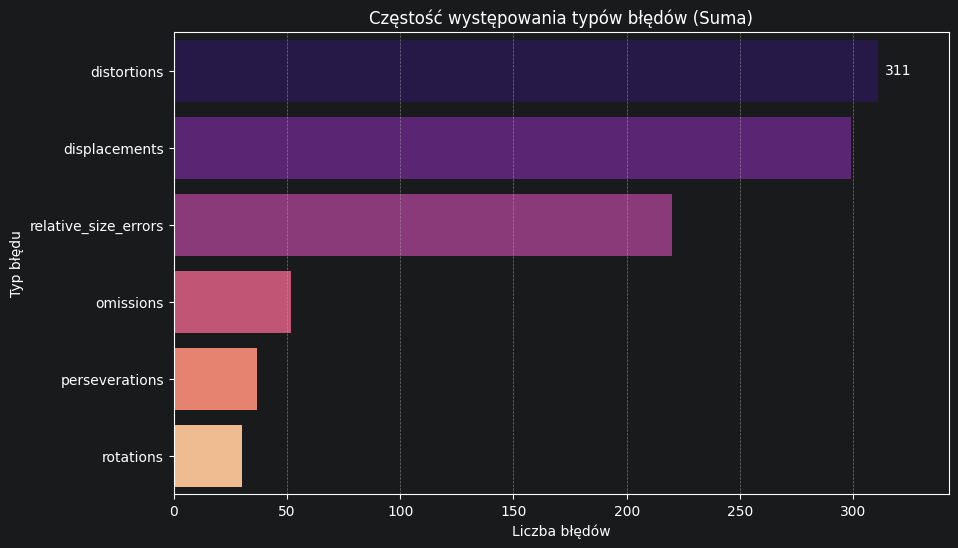

In [45]:
if not df_labels.empty:
    # Obliczenie sumy błędów i posortowanie malejąco
    error_counts = df_labels[error_cols].sum().sort_values(ascending=False)

    # 1. WYPISYWANIE TEKSTOWE W NOTEBOOKU
    print("=== LICZBA WYSTĄPIEŃ POSZCZEGÓLNYCH BŁĘDÓW ===")
    for error_type, count in error_counts.items():
        print(f"{error_type:<25}: {int(count)} os.")
    print("=" * 46)

    # 2. WIZUALIZACJA GRAPH
    plt.figure(figsize=(10, 6))

    # Przypisujemy wykres do zmiennej 'ax', aby móc nim manipulować
    ax = sns.barplot(x=error_counts.values, y=error_counts.index, palette='magma')

    # Dodanie wartości liczbowych na końcach słupków
    ax.bar_label(ax.containers[0], fmt='%d', padding=5)

    plt.title('Częstość występowania typów błędów (Suma)')
    plt.xlabel('Liczba błędów')
    plt.ylabel('Typ błędu')

    # Lekkie zwiększenie limitu osi X, aby wartości tekstowe bar_label nie wychodziły poza wykres
    plt.xlim(0, error_counts.max() * 1.1)

    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

### 2. Korelacja między typami błędów (Heatmap)
Jak silnie poszczególne błędy współwystępują ze sobą.

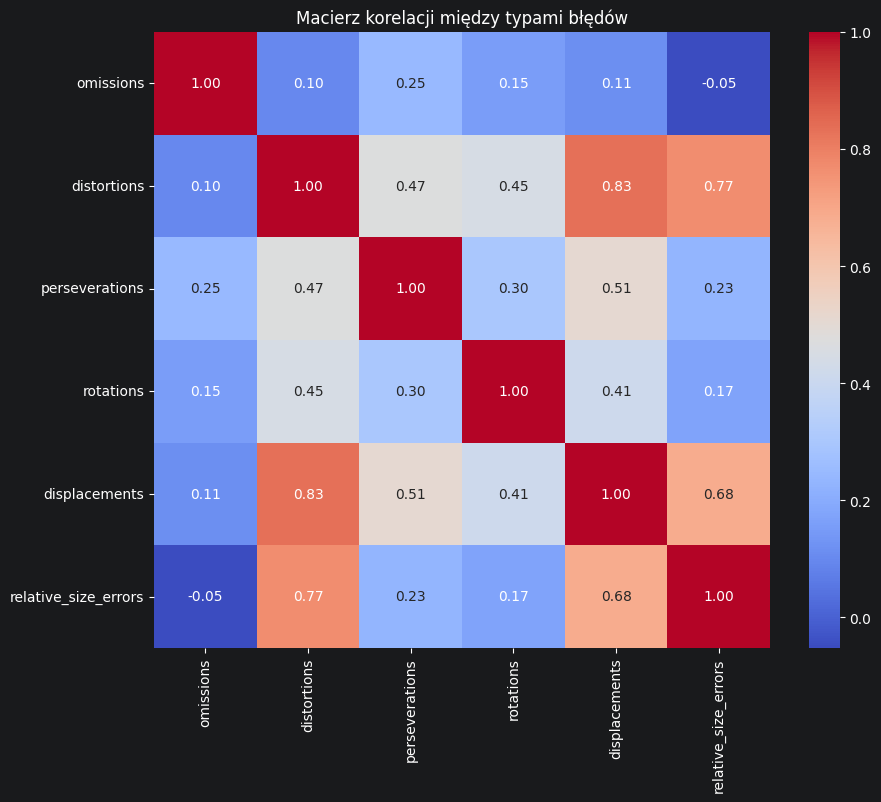

In [33]:
if not df_labels.empty:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_labels[error_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
    plt.title('Macierz korelacji między typami błędów')
    plt.show()

### 3. Profil błędów per Figura (Grouped Bar Chart)
Analiza trudności każdego z 10 wzorców BVRT.

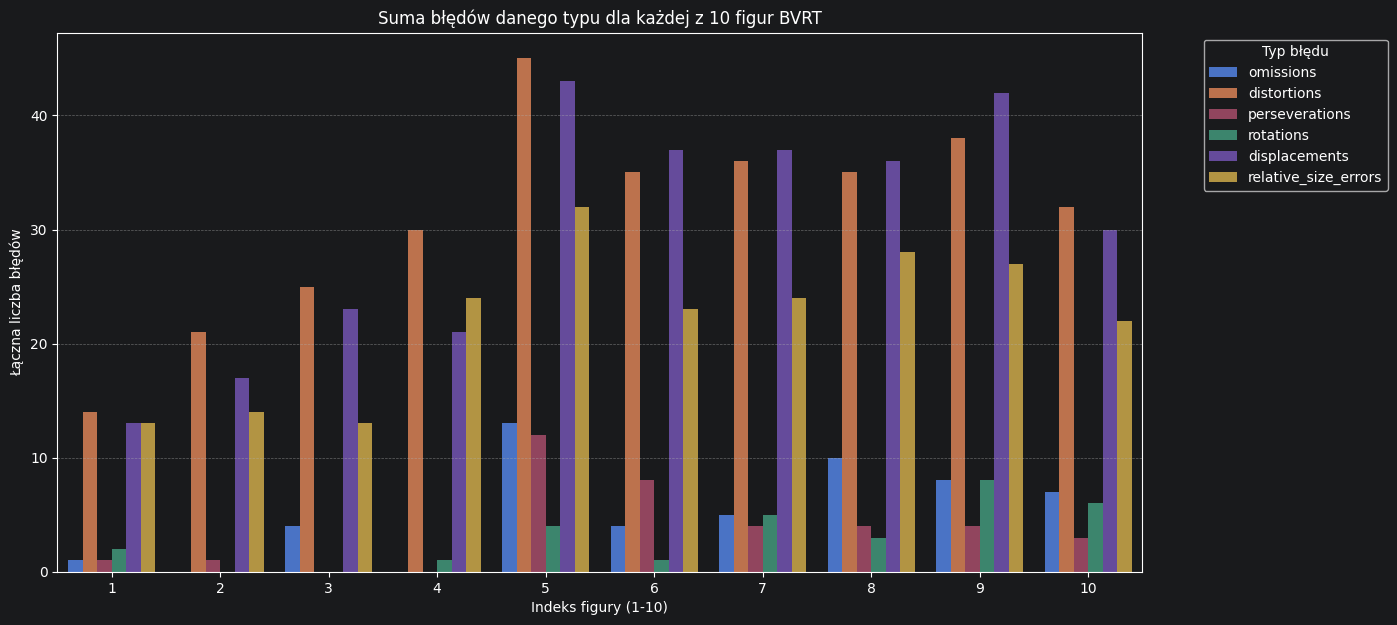

In [34]:
if not df_labels.empty:
    df_melted = df_labels.melt(id_vars=['drawing_id'], value_vars=error_cols, var_name='error_type', value_name='count')
    plt.figure(figsize=(14, 7))
    sns.barplot(x='drawing_id', y='count', hue='error_type', data=df_melted, estimator=np.sum, errorbar=None)
    plt.title('Suma błędów danego typu dla każdej z 10 figur BVRT')
    plt.xlabel('Indeks figury (1-10)')
    plt.ylabel('Łączna liczba błędów')
    plt.legend(title='Typ błędu', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

# Budowa modelu ResNet18 (Transfer Learning)
Definicja architektury sieci ResNet18 z zamrożonymi warstwami bazowymi i nową głową klasyfikacyjną dla zadania multi-label.

In [66]:
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn


class ResNet18Transfer(nn.Module):
    def __init__(self, num_classes=6, freeze_backbone=False, unfreeze_blocks=0, spatial_dropout=0.0):
        super().__init__()
        weights = ResNet18_Weights.DEFAULT
        self.model = resnet18(weights=weights)

        if freeze_backbone:
            for param in self.model.parameters():
                param.requires_grad = False

        if unfreeze_blocks > 0:
            for param in self.model.layer4.parameters():
                param.requires_grad = True

            if spatial_dropout > 0:
                self.model.layer4.add_module("spatial_dropout", nn.Dropout2d(p=spatial_dropout))

            if unfreeze_blocks > 1:
                for param in self.model.layer3.parameters():
                    param.requires_grad = True

        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.model(x)

### Konfiguracja procesu uczenia
Ustawienie funkcji straty BCEWithLogitsLoss oraz optymalizatora Adam tylko dla parametrów ostatniej warstwy.

In [68]:
from sklearn.metrics import f1_score, precision_score, recall_score


class BVRTTrainer:
    def __init__(self, model, criterion, optimizer, device, scheduler=None):
        self.model = model.to(device)
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        self.scheduler = scheduler

    def compute_metrics(self, preds, labels):
        preds_binary = (preds > 0.0).astype(int)
        metrics = {
            "macro_f1": f1_score(labels, preds_binary, average="macro", zero_division=0),
            "micro_f1": f1_score(labels, preds_binary, average="micro", zero_division=0),
            "macro_precision": precision_score(labels, preds_binary, average="macro", zero_division=0),
            "macro_recall": recall_score(labels, preds_binary, average="macro", zero_division=0),
        }
        return metrics

    def train_one_epoch(self, train_loader):
        self.model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images = images.to(self.device)
            labels = labels.to(self.device)
            if len(labels.shape) == 1: labels = labels.unsqueeze(1)
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()
            running_loss += loss.item() * images.size(0)
        return running_loss / len(train_loader.dataset)

    def evaluate(self, val_loader):
        self.model.eval()
        running_loss = 0.0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                if len(labels.shape) == 1: labels = labels.unsqueeze(1)
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)
                all_preds.append(outputs.cpu().numpy())
                all_labels.append(labels.cpu().numpy())
        epoch_loss = running_loss / len(val_loader.dataset)
        all_preds = np.vstack(all_preds)
        all_labels = np.vstack(all_labels)
        return epoch_loss, all_preds, all_labels


# Walidacja Leave-One-Subject-Out (LOSO)
Ten proces trenuje osobny model dla każdego pacjenta, używając go jako zbioru walidacyjnego, a pozostałych pacjentów jako zbioru treningowego. Gwarantuje to brak wycieku danych pacjenta.

In [69]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy


def calculate_pos_weights(dataset, device):
    all_labels = []
    for i in range(len(dataset)):
        _, labels = dataset[i]
        all_labels.append(labels)

    all_labels = torch.stack(all_labels)
    positives = all_labels.sum(dim=0)
    negatives = len(dataset) - positives
    pos_weight = negatives / (positives + 1e-5)
    return pos_weight.to(device)


def run_loso_training_with_logging(root_dir, num_epochs=20, inspect_every_n_epochs=None, label_smoothing=0.0,
                                   spatial_dropout=0.0):
    root_path = Path(root_dir)
    patients = sorted([d.name for d in root_path.iterdir() if d.is_dir()])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Starting LOSO on {len(patients)} patients with improvements...")
    loso_history = {}
    target_names = ["omissions", "distortions", "perseverations", "rotations", "displacements", "relative_size_errors"]

    for test_patient in patients:
        train_patients = [p for p in patients if p != test_patient]
        print(f"=== Fold: Test Patient = {test_patient} ===")

        train_ds = BVRTDataset(root_dir, patient_ids=train_patients, transform=train_transforms)
        val_ds = BVRTDataset(root_dir, patient_ids=[test_patient], transform=val_transforms)

        current_pos_weight = calculate_pos_weights(train_ds, device)
        print(f"Dynamic pos_weight for this fold: {current_pos_weight.cpu().numpy()}")

        train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

        model = ResNet18Transfer(num_classes=6, freeze_backbone=True, unfreeze_blocks=1,
                                 spatial_dropout=spatial_dropout)

        try:
            criterion = nn.BCEWithLogitsLoss(pos_weight=current_pos_weight, label_smoothing=label_smoothing)
            print(f"Using built-in Label Smoothing: {label_smoothing}")
        except TypeError:
            criterion = nn.BCEWithLogitsLoss(pos_weight=current_pos_weight)
            print("BCEWithLogitsLoss does not support label_smoothing. Manual smoothing would be needed.")

        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4)
        scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

        trainer = BVRTTrainer(model, criterion, optimizer, device, scheduler=scheduler)
        history = {"train_loss": [], "val_loss": [], "macro_f1": [], "micro_f1": []}

        best_val_loss = float("inf")
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        early_stopping_patience = 3

        for epoch in range(num_epochs):
            train_loss = trainer.train_one_epoch(train_loader)
            val_loss, preds, labels = trainer.evaluate(val_loader)
            metrics = trainer.compute_metrics(preds, labels)

            if scheduler: scheduler.step(val_loss)

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["macro_f1"].append(metrics["macro_f1"])
            history["micro_f1"].append(metrics["micro_f1"])

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                patience_counter = 0
                print(f"Epoch {epoch + 1}: New best val_loss: {val_loss:.4f}")
            else:
                patience_counter += 1

            if patience_counter >= early_stopping_patience:
                print(f"Early stopping triggered at epoch {epoch + 1}")
                break

            if inspect_every_n_epochs and (epoch + 1) % inspect_every_n_epochs == 0:
                print(f"--- Inspection at Epoch {epoch + 1} ---")
                inspect_predictions(model, val_loader, device, target_names, num_cases=2)

        model.load_state_dict(best_model_wts)
        loso_history[test_patient] = history
        print(f"Fold {test_patient} finished. Best Val Loss: {best_val_loss:.4f}")

        print(f"--- Final Predictions (Best Model) for {test_patient} ---")
        inspect_predictions(model, val_loader, device, target_names, num_cases=3)

    return loso_history

In [70]:
def inspect_predictions(model, dataloader, device, target_names, num_cases=3):
    model.eval()
    images_shown = 0

    # Funkcja pomocnicza do odwrócenia normalizacji ImageNet na potrzeby wyświetlania obrazu
    def denormalize(tensor):
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = tensor.permute(1, 2, 0).cpu().numpy()
        img = img * std + mean
        img = np.clip(img, 0, 1)
        return img

    with torch.no_grad():
        for images, labels in dataloader:
            images_dev = images.to(device)
            outputs = model(images_dev)
            # Zamieniamy logity na prawdopodobieństwa (0.0 - 1.0)
            probs = torch.sigmoid(outputs).cpu().numpy()
            labels = labels.numpy()

            for i in range(images.size(0)):
                if images_shown >= num_cases:
                    return

                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

                # 1. Wyświetlenie 3-kanałowego obrazu (Rysunek + Wzorzec + Różnica)
                vis_img = denormalize(images[i])
                ax1.imshow(vis_img)
                ax1.set_title(f"Przypadek testowy {images_shown + 1}")
                ax1.axis('off')

                # 2. Wykres słupkowy prawdopodobieństw
                y_pos = np.arange(len(target_names))

                # Rysujemy słupki predykcji sieci
                bars = ax2.barh(y_pos, probs[i], color='skyblue', alpha=0.8, label='Predykcja sieci')

                # Zaznaczamy kropkami faktyczne błędy (Ground Truth)
                for idx, label_val in enumerate(labels[i]):
                    if label_val == 1.0:
                        ax2.scatter(1.05, idx, color='red', marker='X', s=100,
                                    label='Prawdziwy Błąd' if idx == 0 else "")

                # Linia progowa 0.5
                ax2.axvline(x=0.5, color='orange', linestyle='--', label='Próg odcięcia (0.5)')

                ax2.set_yticks(y_pos)
                ax2.set_yticklabels(target_names)
                ax2.set_xlim(0, 1.15)
                ax2.set_xlabel('Prawdopodobieństwo błędu')
                ax2.set_title('Porównanie: Sieć vs Rzeczywistość')

                # Dodanie wartości tekstowych na słupkach
                for bar in bars:
                    width = bar.get_width()
                    ax2.text(width + 0.01, bar.get_y() + bar.get_height() / 2, f'{width:.2f}',
                             va='center', ha='left', fontsize=9)

                plt.tight_layout()
                plt.show()

                images_shown += 1

In [80]:
def plot_loso_history(loso_history, patient_id=None):
    """
    Rysuje wykresy dla wybranego pacjenta lub uśrednioną historię po wszystkich foldach.
    Bezpieczna dla Early Stopping - obsługuje foldy o różnej liczbie epok.
    """
    if patient_id and patient_id in loso_history:
        folds_to_plot = {patient_id: loso_history[patient_id]}
        title_suffix = f" - Pacjent: {patient_id}"
        mode_text = f"RAPORT DLA PACJENTA: {patient_id}"
    else:
        folds_to_plot = loso_history
        title_suffix = " - Średnia ze wszystkich foldów"
        mode_text = "RAPORT ŚREDNI ZE WSZYSTKICH FOLDÓW LOSO"

    num_folds = len(folds_to_plot)

    # 1. Znajdź maksymalną liczbę epok wśród wszystkich analizowanych foldów
    max_epochs = max(len(f_hist['train_loss']) for f_hist in folds_to_plot.values())

    # Przygotowanie tablic na uśrednione wartości o długości max_epochs
    avg_train_loss = np.zeros(max_epochs)
    avg_val_loss = np.zeros(max_epochs)
    avg_macro_f1 = np.zeros(max_epochs)
    avg_micro_f1 = np.zeros(max_epochs)

    # 2. Agregacja danych z foldów (z inteligentnym dopełnianiem)
    for f_hist in folds_to_plot.values():
        current_len = len(f_hist['train_loss'])

        # Pobieramy oryginalne tablice
        t_loss = np.array(f_hist['train_loss'])
        v_loss = np.array(f_hist['val_loss'])
        ma_f1 = np.array(f_hist['macro_f1'])
        mi_f1 = np.array(f_hist['micro_f1'])

        # Jeśli ten fold skończył się wcześniej, dopełniamy go ostatnią zarejestrowaną wartością
        if current_len < max_epochs:
            padding_len = max_epochs - current_len
            t_loss = np.pad(t_loss, (0, padding_len), mode='edge')
            v_loss = np.pad(v_loss, (0, padding_len), mode='edge')
            ma_f1 = np.pad(ma_f1, (0, padding_len), mode='edge')
            mi_f1 = np.pad(mi_f1, (0, padding_len), mode='edge')

        avg_train_loss += t_loss
        avg_val_loss += v_loss
        avg_macro_f1 += ma_f1
        avg_micro_f1 += mi_f1

    # Obliczenie średniej
    avg_train_loss /= num_folds
    avg_val_loss /= num_folds
    avg_macro_f1 /= num_folds
    avg_micro_f1 /= num_folds

    # --- GENEROWANIE TEKSTU DLA LLM ---
    llm_output = []
    llm_output.append(f"```text\n=== {mode_text} ===")
    llm_output.append(f"Liczba uwzględnionych foldów/pacjentów: {num_folds}")
    llm_output.append(f"Maksymalna liczba epok treningu: {max_epochs}\n")

    # Tabela z głównymi metrykami
    llm_output.append(f"{'Epoka':<6} | {'Train Loss':<10} | {'Val Loss':<10} | {'Macro F1':<8} | {'Micro F1':<8}")
    llm_output.append("-" * 55)

    for epoch in range(max_epochs):
        llm_output.append(
            f"{epoch + 1:<6} | {avg_train_loss[epoch]:<10.4f} | {avg_val_loss[epoch]:<10.4f} | "
            f"{avg_macro_f1[epoch]:<8.4f} | {avg_micro_f1[epoch]:<8.4f}"
        )
    llm_output.append("```")

    # Wypisanie sformatowanego raportu do konsoli
    print("\n".join(llm_output))
    print("\n" + "=" * 50 + "\n")

    # --- RYSOWANIE WYKRESÓW ---
    epochs = range(1, max_epochs + 1)
    plt.figure(figsize=(14, 5))

    # Wykres Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, avg_train_loss, 'b-o', label='Train Loss')
    plt.plot(epochs, avg_val_loss, 'r-o', label='Val Loss')
    plt.title(f'Krzywa Straty (Loss){title_suffix}')
    plt.xlabel('Epoka')
    plt.ylabel('BCE Loss')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    # Wykres F1 Scores
    plt.subplot(1, 2, 2)
    plt.plot(epochs, avg_macro_f1, 'g-s', label='Val Macro F1')
    plt.plot(epochs, avg_micro_f1, 'm-^', label='Val Micro F1', alpha=0.7)
    plt.title(f'Krzywe Jakości F1{title_suffix}')
    plt.xlabel('Epoka')
    plt.ylabel('F1 Score')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()

Starting LOSO on 14 patients with improvements...
=== Fold: Test Patient = Aniela_Sonczewa ===
Dynamic pos_weight for this fold: [2.2499993  0.04       3.3333323  3.642856   0.08333333 0.08333333]
BCEWithLogitsLoss does not support label_smoothing. Manual smoothing would be needed.
Epoch 1: New best val_loss: 0.6701
Epoch 2: New best val_loss: 0.4515
Epoch 4: New best val_loss: 0.3879
Early stopping triggered at epoch 10
Fold Aniela_Sonczewa finished. Best Val Loss: 0.3879
--- Final Predictions (Best Model) for Aniela_Sonczewa ---


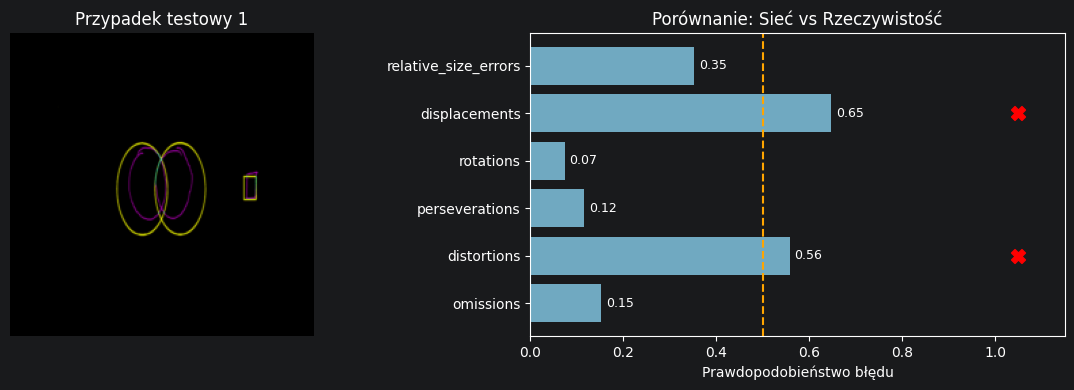

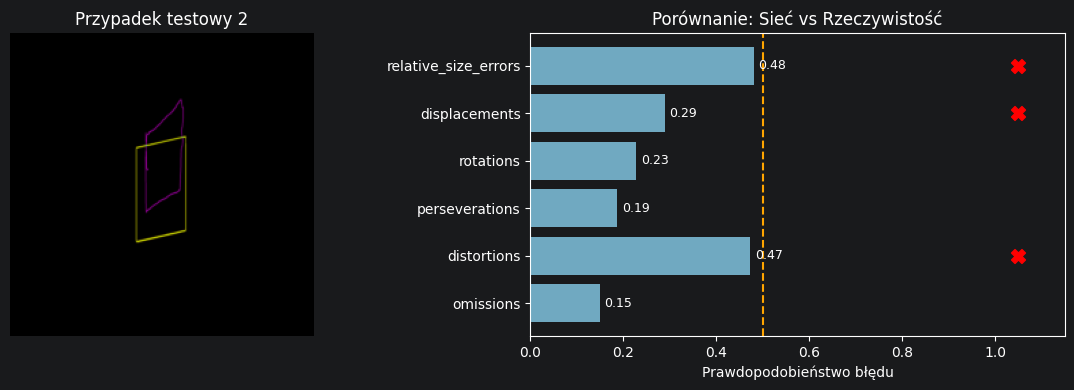

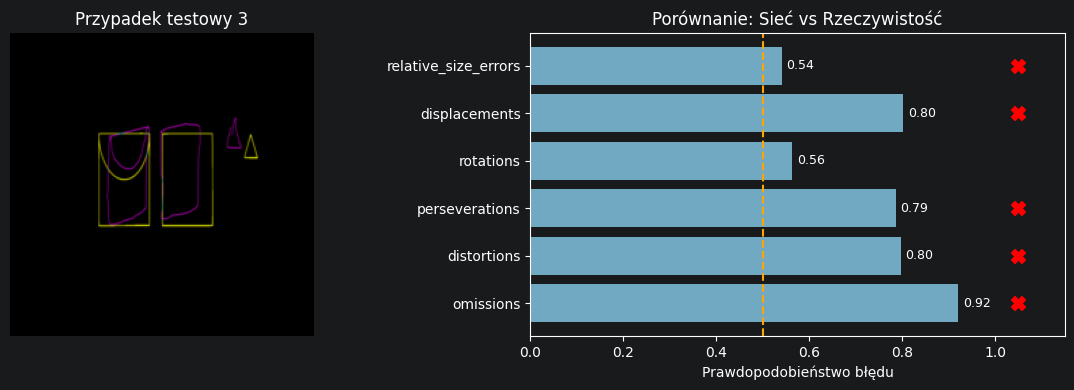

=== Fold: Test Patient = Antonina_Lonc ===
Dynamic pos_weight for this fold: [2.3333325  0.04       2.9393928  3.8148134  0.08333333 0.09243697]
BCEWithLogitsLoss does not support label_smoothing. Manual smoothing would be needed.
Epoch 1: New best val_loss: 0.5416
Epoch 2: New best val_loss: 0.4548
Epoch 3: New best val_loss: 0.4423
Epoch 4: New best val_loss: 0.3973
Epoch 5: New best val_loss: 0.3702
Epoch 8: New best val_loss: 0.3652
Epoch 9: New best val_loss: 0.3350
--- Inspection at Epoch 10 ---


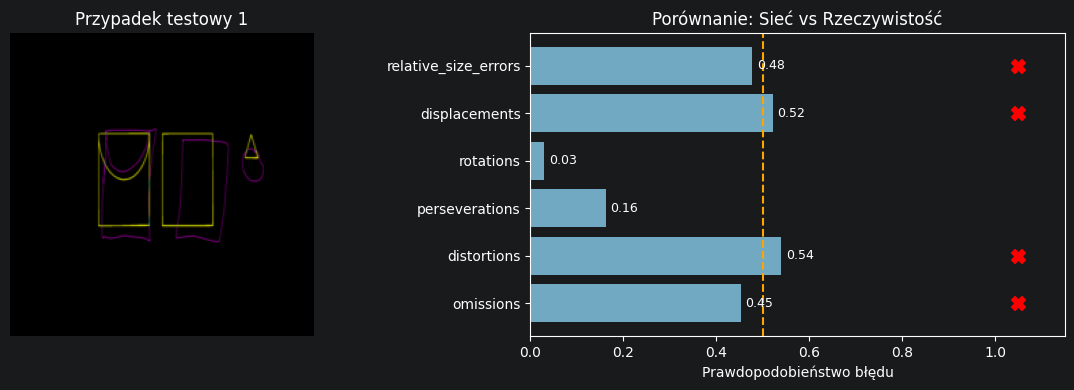

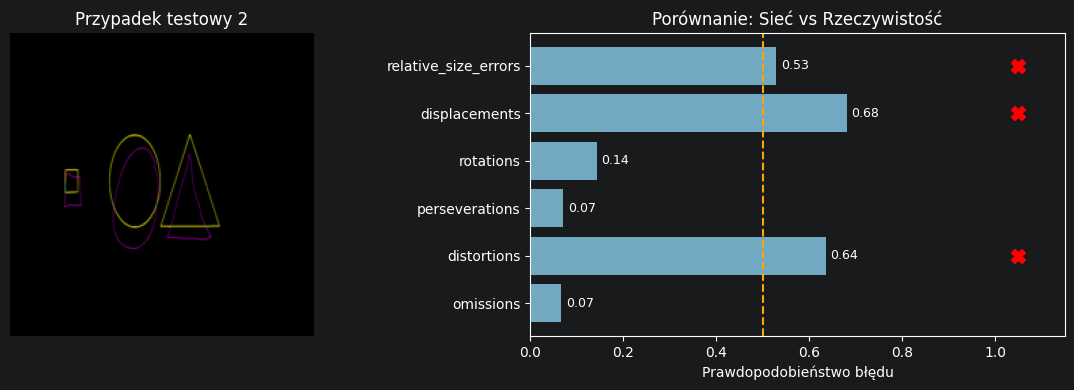

Early stopping triggered at epoch 15
Fold Antonina_Lonc finished. Best Val Loss: 0.3350
--- Final Predictions (Best Model) for Antonina_Lonc ---


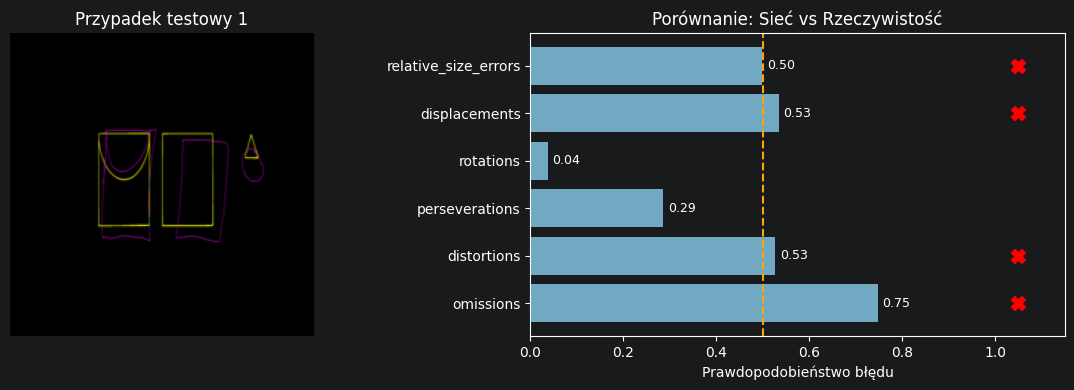

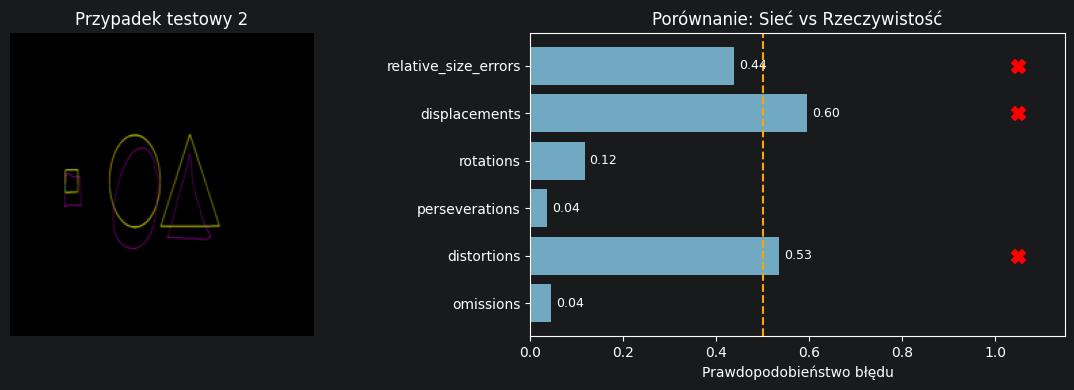

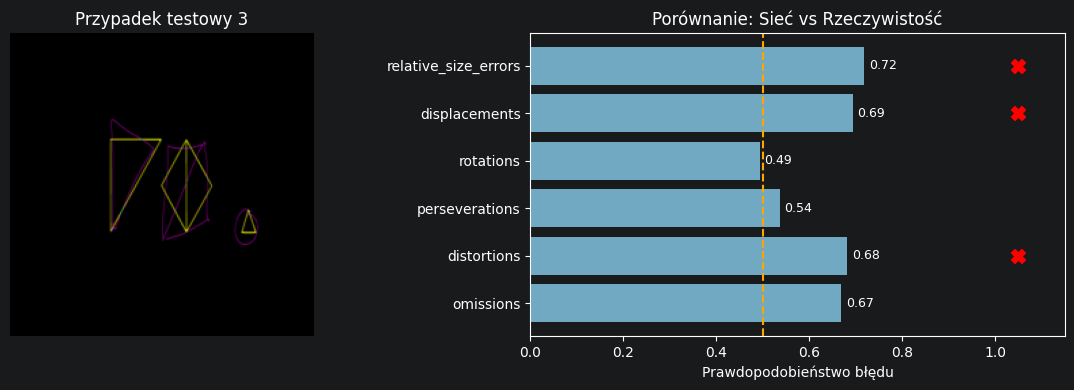

=== Fold: Test Patient = Franciszek_Lonc ===
Dynamic pos_weight for this fold: [2.3333325  0.04       3.0624988  3.9999986  0.09243697 0.09243697]
BCEWithLogitsLoss does not support label_smoothing. Manual smoothing would be needed.
Epoch 1: New best val_loss: 0.4784
Epoch 2: New best val_loss: 0.3430
Epoch 3: New best val_loss: 0.3090
Early stopping triggered at epoch 9
Fold Franciszek_Lonc finished. Best Val Loss: 0.3090
--- Final Predictions (Best Model) for Franciszek_Lonc ---


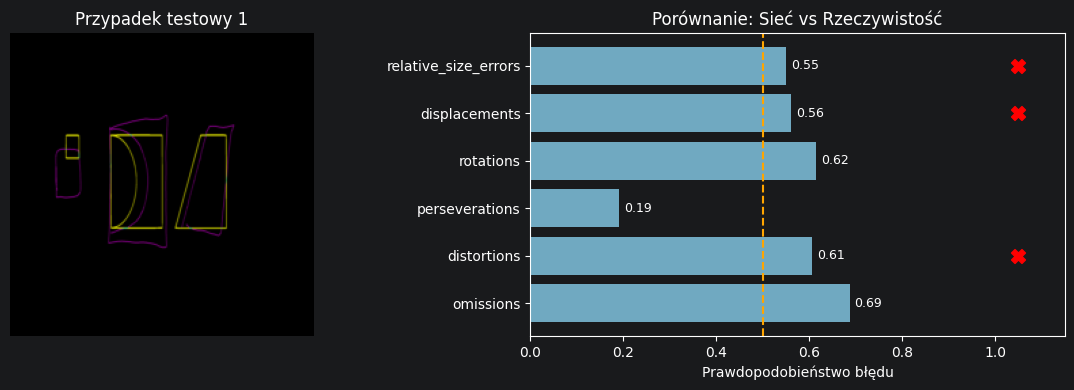

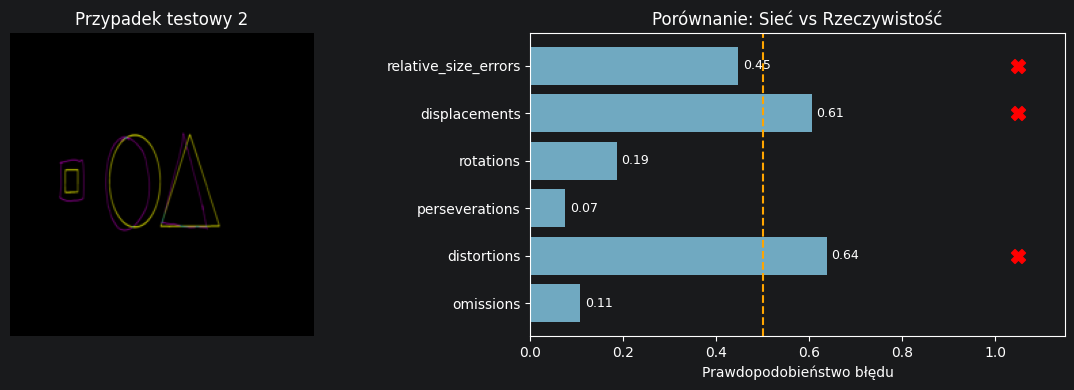

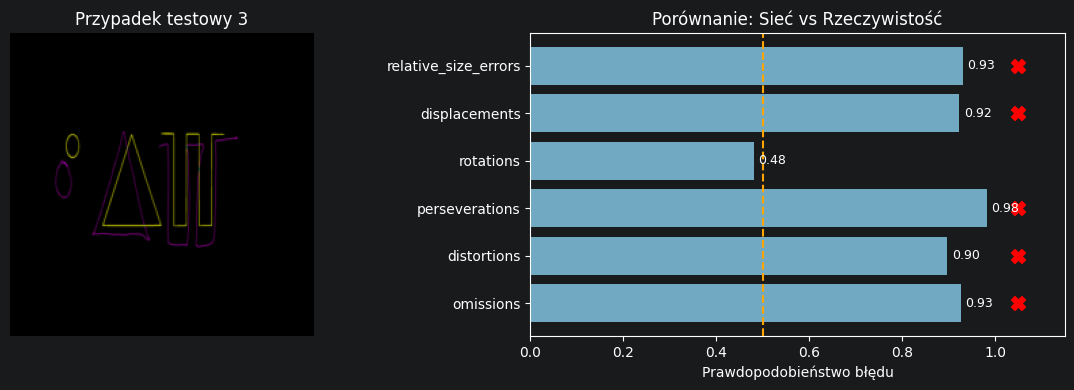

=== Fold: Test Patient = Jakub_B ===
Dynamic pos_weight for this fold: [2.2499993  0.04       3.1935475  4.416665   0.09243697 0.09243697]
BCEWithLogitsLoss does not support label_smoothing. Manual smoothing would be needed.
Epoch 1: New best val_loss: 0.5358
Epoch 2: New best val_loss: 0.5064
Epoch 4: New best val_loss: 0.4788
Epoch 5: New best val_loss: 0.4768
Epoch 6: New best val_loss: 0.4322
--- Inspection at Epoch 10 ---


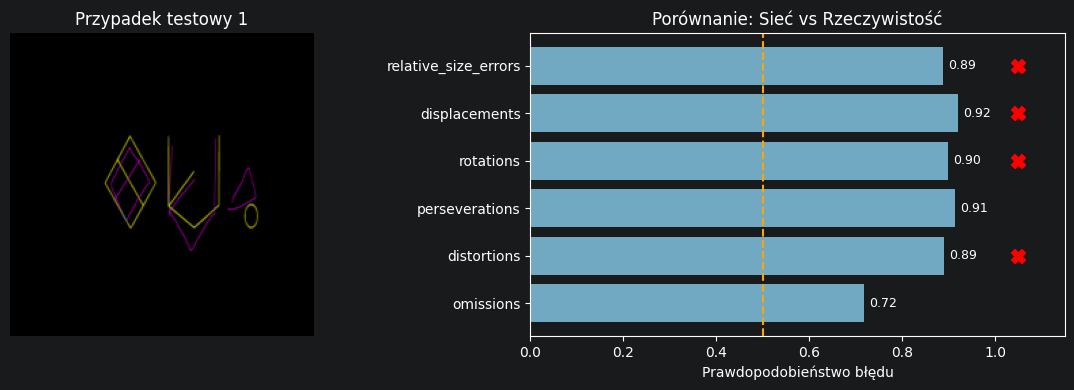

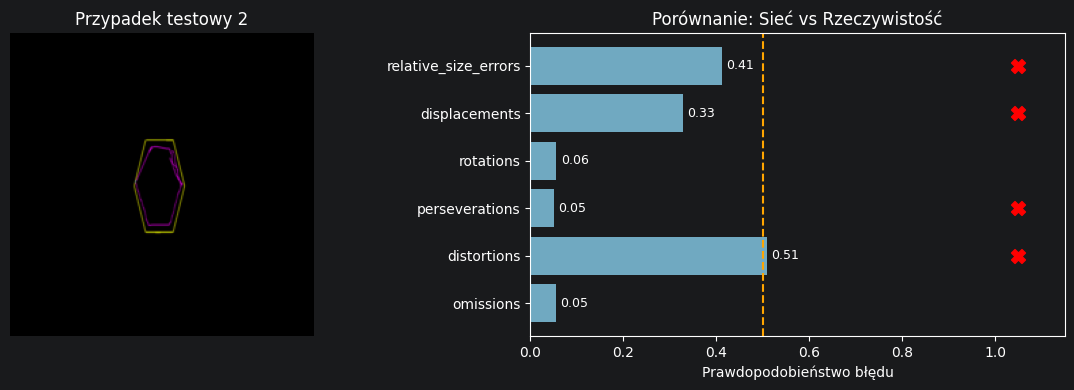

Early stopping triggered at epoch 12
Fold Jakub_B finished. Best Val Loss: 0.4322
--- Final Predictions (Best Model) for Jakub_B ---


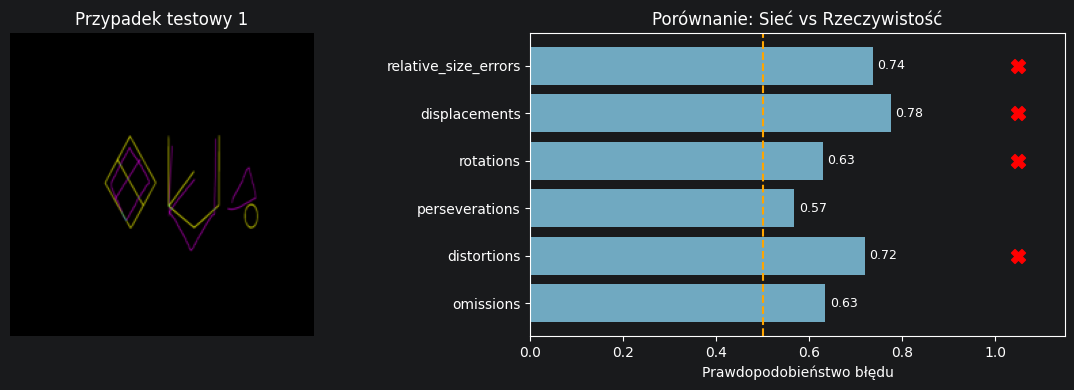

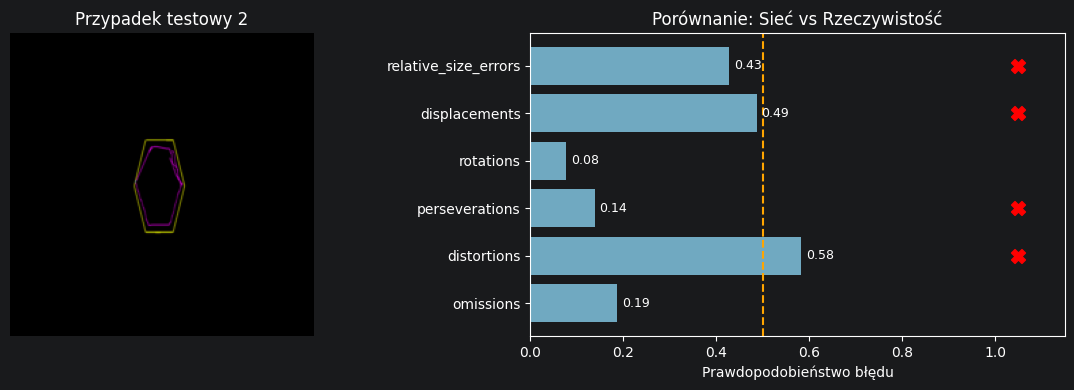

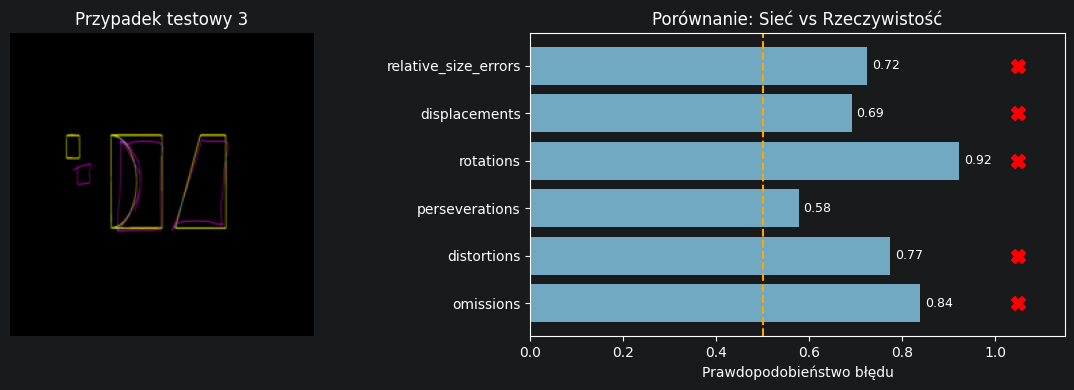

=== Fold: Test Patient = Kacper_B ===
Dynamic pos_weight for this fold: [2.421052   0.04       3.0624988  4.652172   0.09243697 0.09243697]
BCEWithLogitsLoss does not support label_smoothing. Manual smoothing would be needed.
Epoch 1: New best val_loss: 0.8203
Epoch 2: New best val_loss: 0.7948
Epoch 5: New best val_loss: 0.6916
--- Inspection at Epoch 10 ---


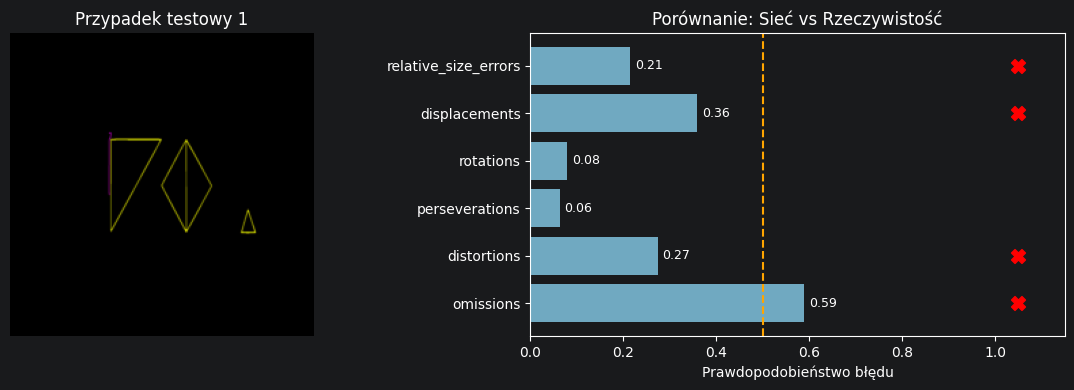

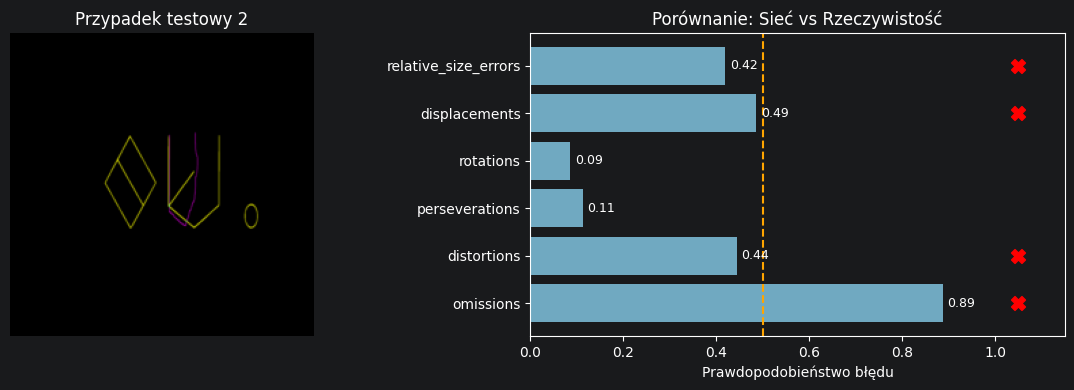

Early stopping triggered at epoch 11
Fold Kacper_B finished. Best Val Loss: 0.6916
--- Final Predictions (Best Model) for Kacper_B ---


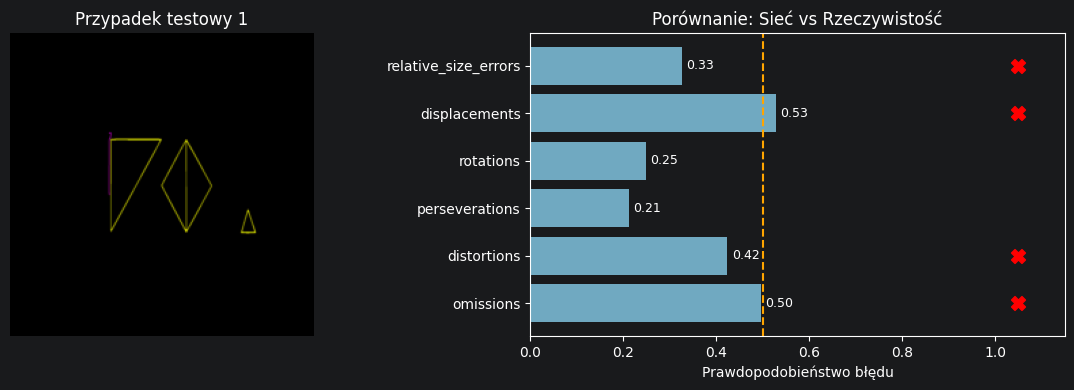

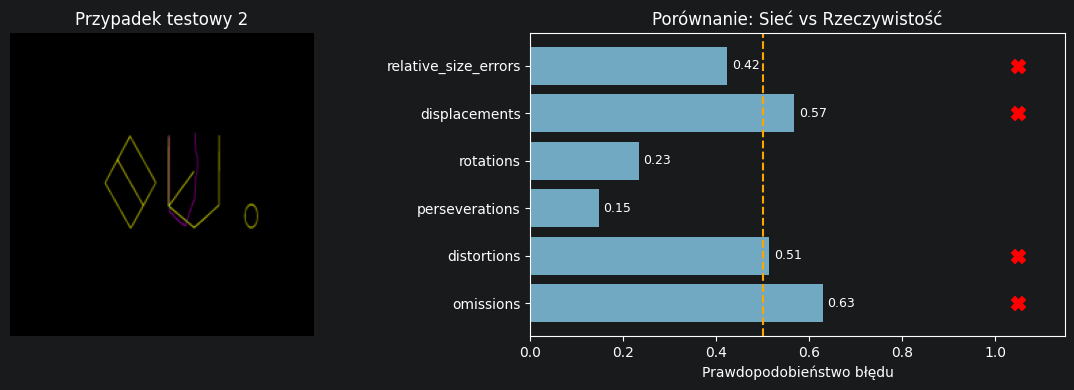

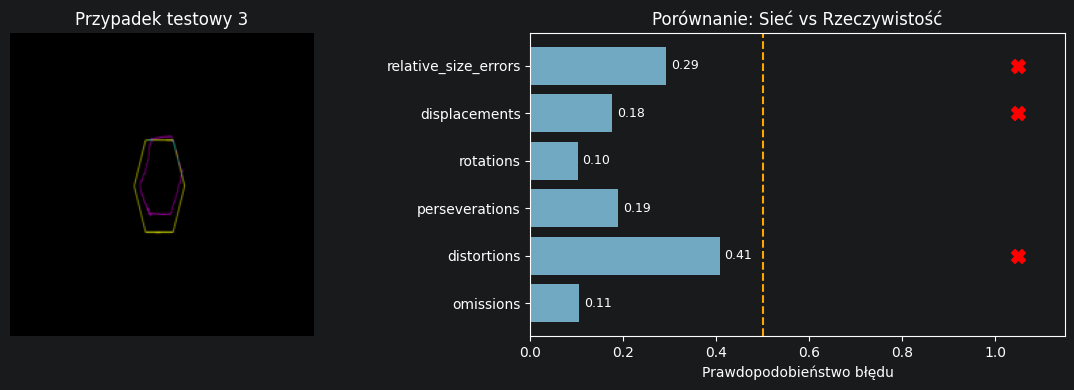

=== Fold: Test Patient = Karol_K ===
Dynamic pos_weight for this fold: [2.3333325  0.03174603 3.3333323  4.652172   0.07438016 0.08333333]
BCEWithLogitsLoss does not support label_smoothing. Manual smoothing would be needed.
Epoch 1: New best val_loss: 0.6048
Epoch 2: New best val_loss: 0.4401
Epoch 4: New best val_loss: 0.4197
Epoch 5: New best val_loss: 0.3867
--- Inspection at Epoch 10 ---


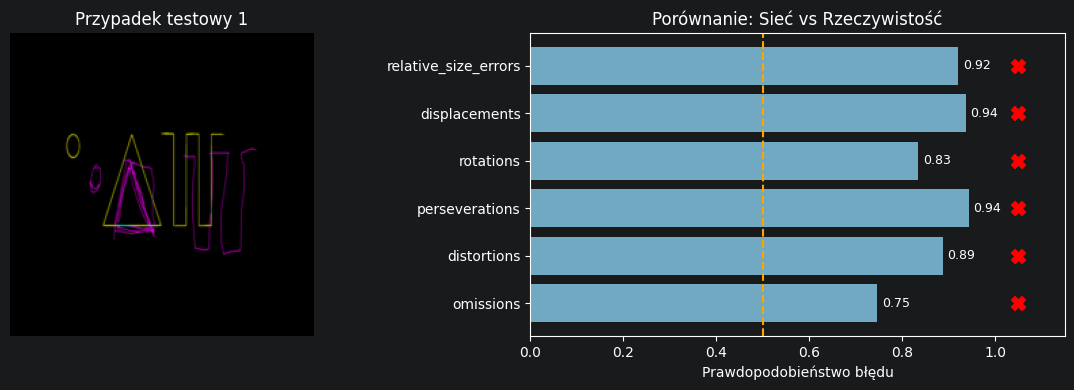

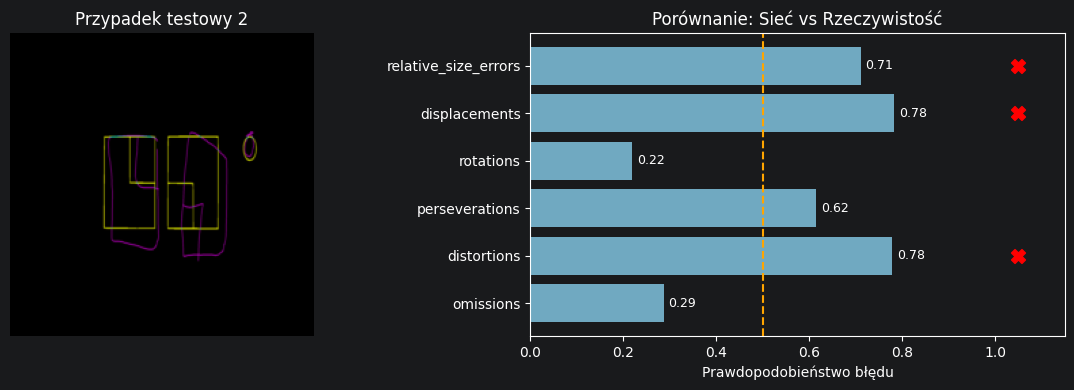

Epoch 11: New best val_loss: 0.3737
Early stopping triggered at epoch 17
Fold Karol_K finished. Best Val Loss: 0.3737
--- Final Predictions (Best Model) for Karol_K ---


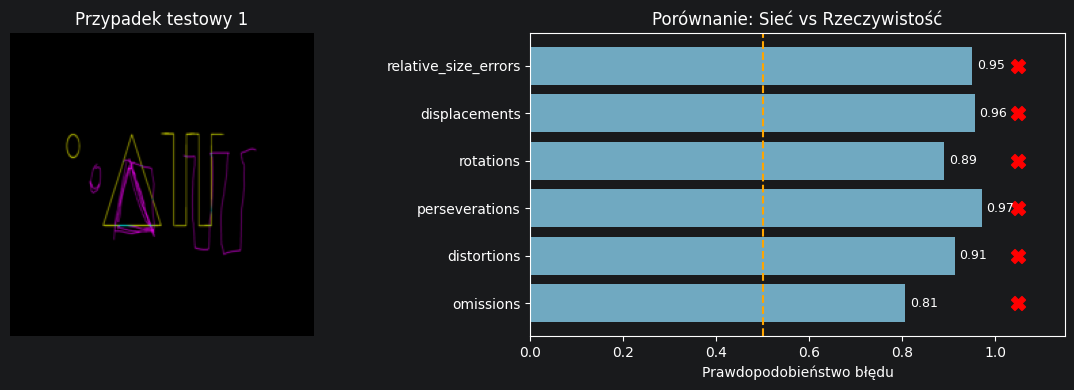

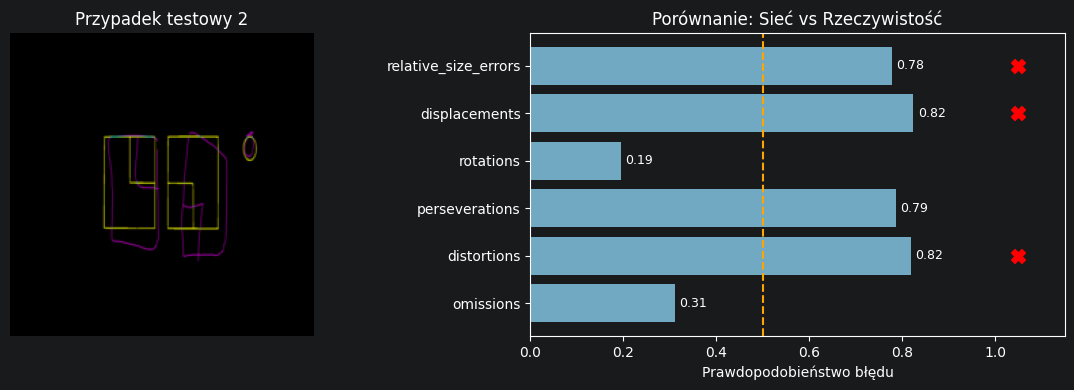

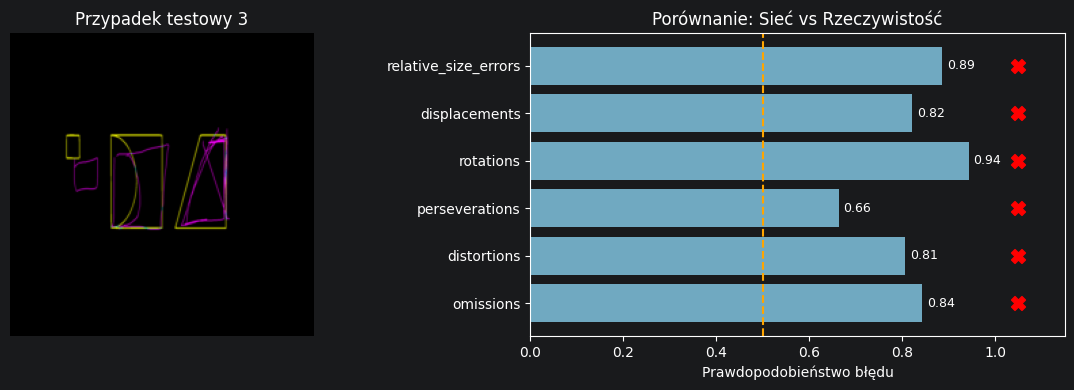

=== Fold: Test Patient = Karolina_Witanek ===
Dynamic pos_weight for this fold: [2.3333325  0.02362205 2.9393928  3.642856   0.07438016 0.05691057]
BCEWithLogitsLoss does not support label_smoothing. Manual smoothing would be needed.
Epoch 1: New best val_loss: 0.6057
Epoch 2: New best val_loss: 0.5760
Epoch 3: New best val_loss: 0.5125
Epoch 4: New best val_loss: 0.4829
Epoch 5: New best val_loss: 0.4296
Epoch 6: New best val_loss: 0.4120
Epoch 7: New best val_loss: 0.3550
--- Inspection at Epoch 10 ---


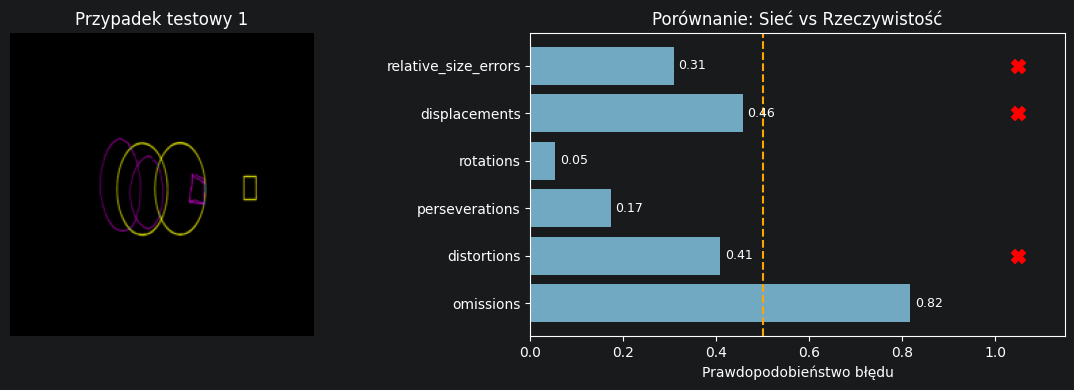

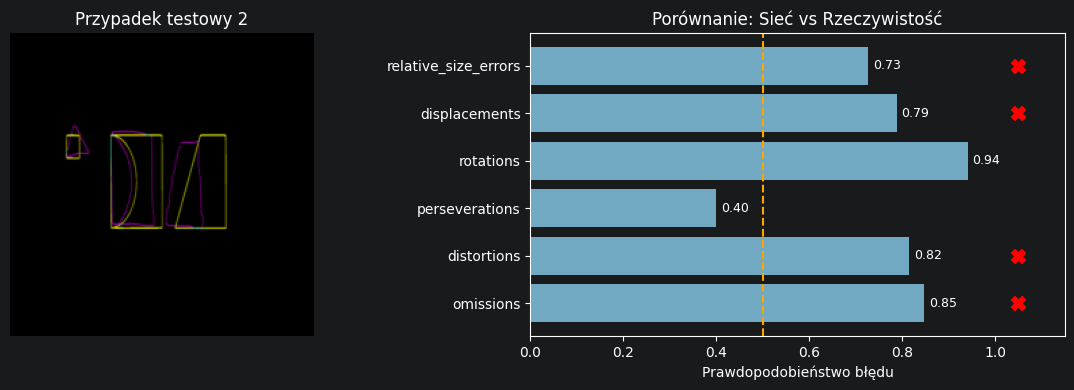

Early stopping triggered at epoch 13
Fold Karolina_Witanek finished. Best Val Loss: 0.3550
--- Final Predictions (Best Model) for Karolina_Witanek ---


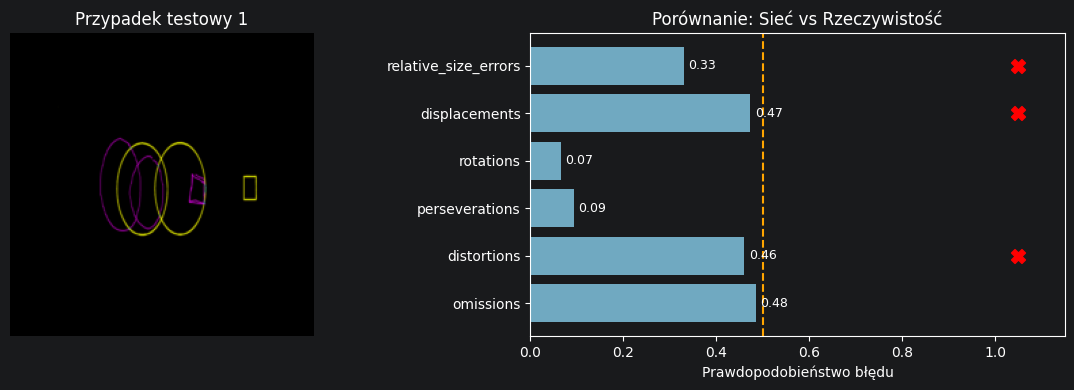

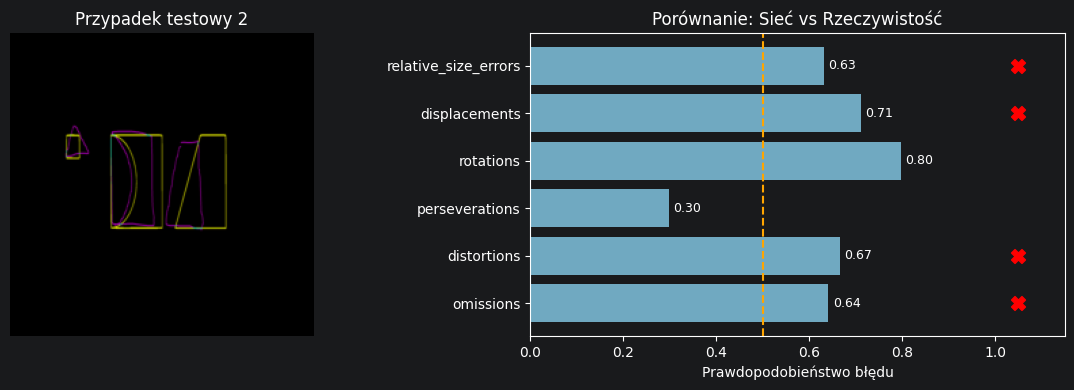

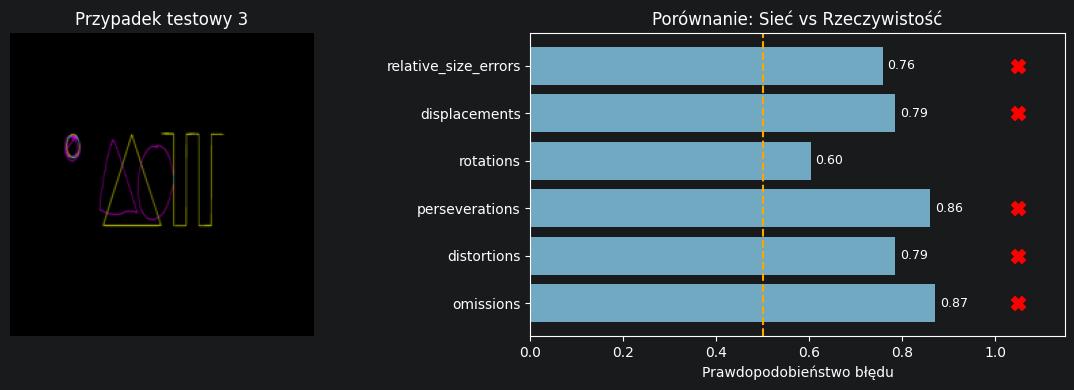

=== Fold: Test Patient = Liliana_B ===
Dynamic pos_weight for this fold: [2.170731   0.04       2.9393928  3.8148134  0.09243697 0.09243697]
BCEWithLogitsLoss does not support label_smoothing. Manual smoothing would be needed.
Epoch 1: New best val_loss: 0.4476
Early stopping triggered at epoch 7
Fold Liliana_B finished. Best Val Loss: 0.4476
--- Final Predictions (Best Model) for Liliana_B ---


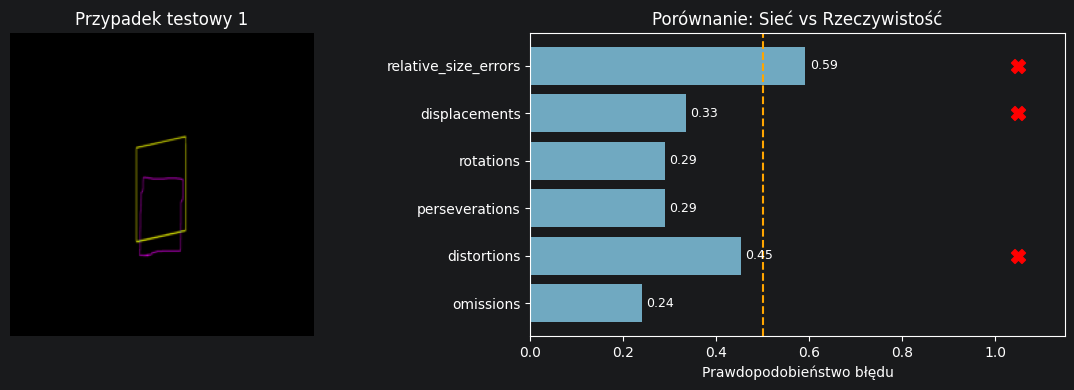

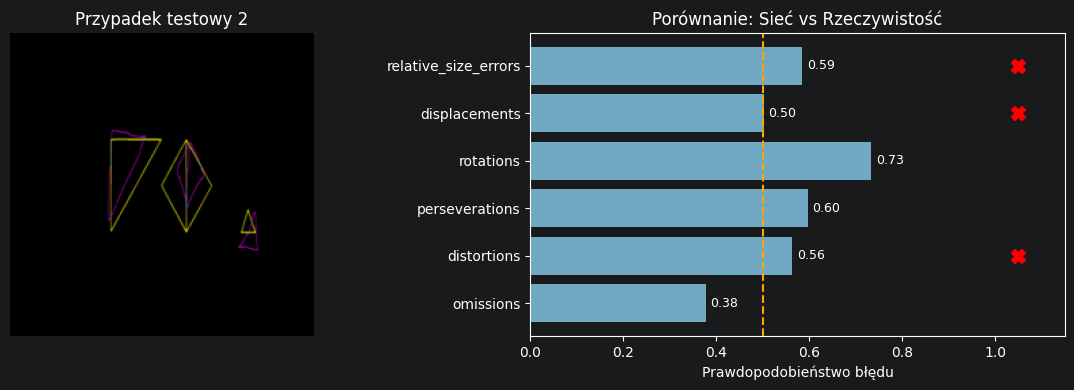

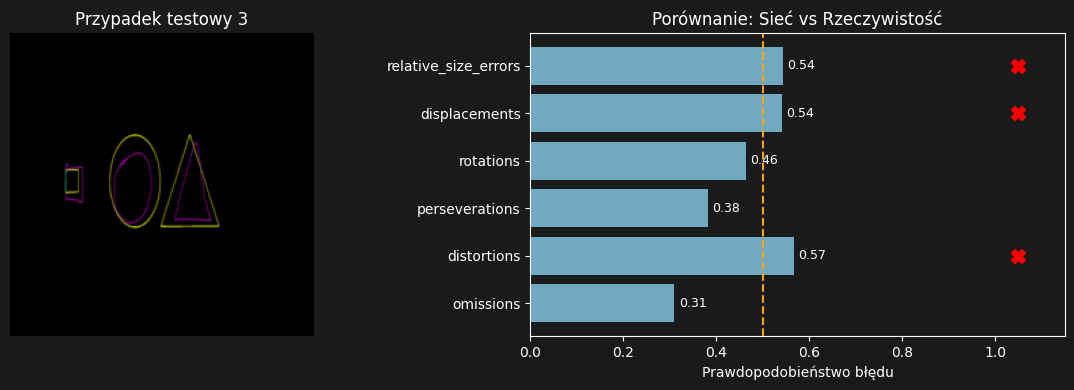

=== Fold: Test Patient = Maja_B ===
Dynamic pos_weight for this fold: [2.3333325  0.03174603 3.0624988  3.8148134  0.08333333 0.07438016]
BCEWithLogitsLoss does not support label_smoothing. Manual smoothing would be needed.
Epoch 1: New best val_loss: 0.5828
Epoch 2: New best val_loss: 0.5779
Early stopping triggered at epoch 8
Fold Maja_B finished. Best Val Loss: 0.5779
--- Final Predictions (Best Model) for Maja_B ---


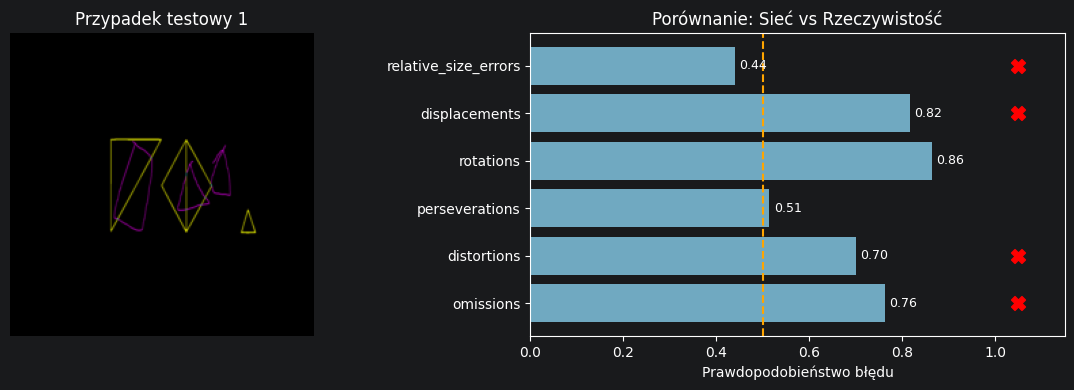

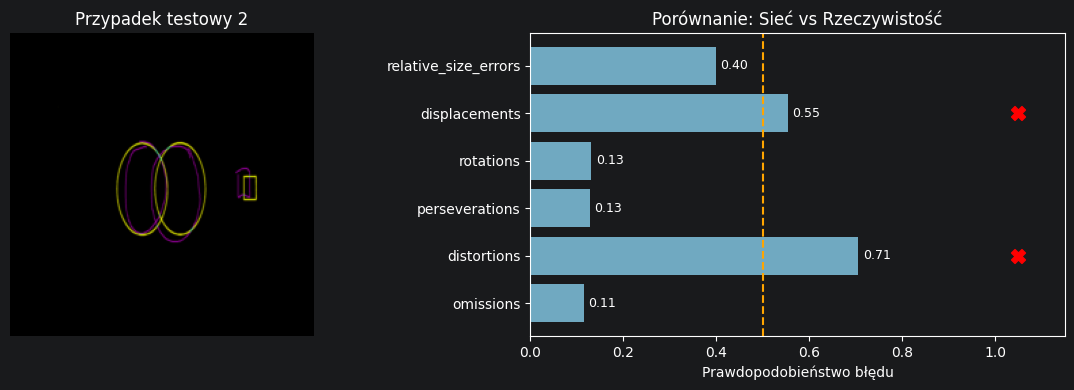

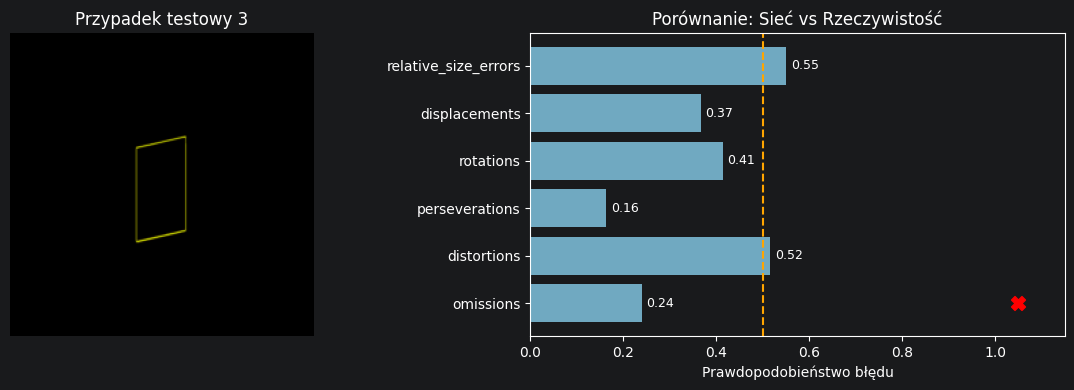

=== Fold: Test Patient = Michal_B ===
Dynamic pos_weight for this fold: [2.0232553  0.04       2.9393928  4.1999984  0.09243697 0.09243697]
BCEWithLogitsLoss does not support label_smoothing. Manual smoothing would be needed.
Epoch 1: New best val_loss: 0.5053
Epoch 2: New best val_loss: 0.4961
Epoch 3: New best val_loss: 0.4442
Epoch 6: New best val_loss: 0.4297
--- Inspection at Epoch 10 ---


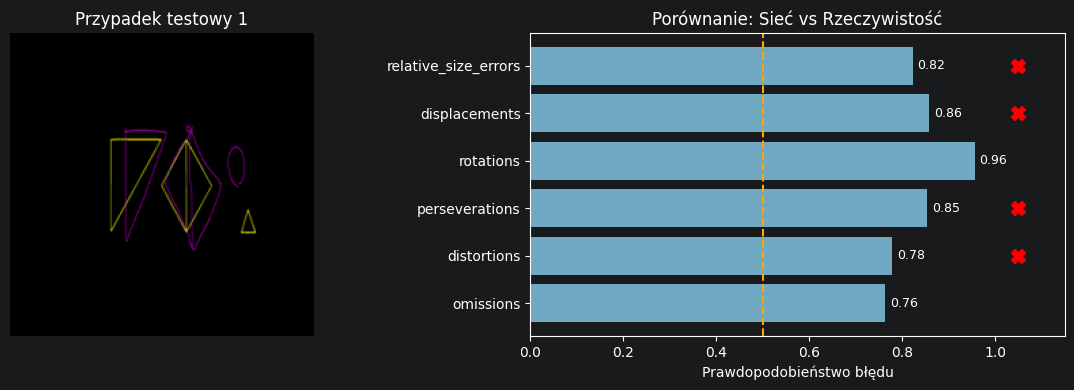

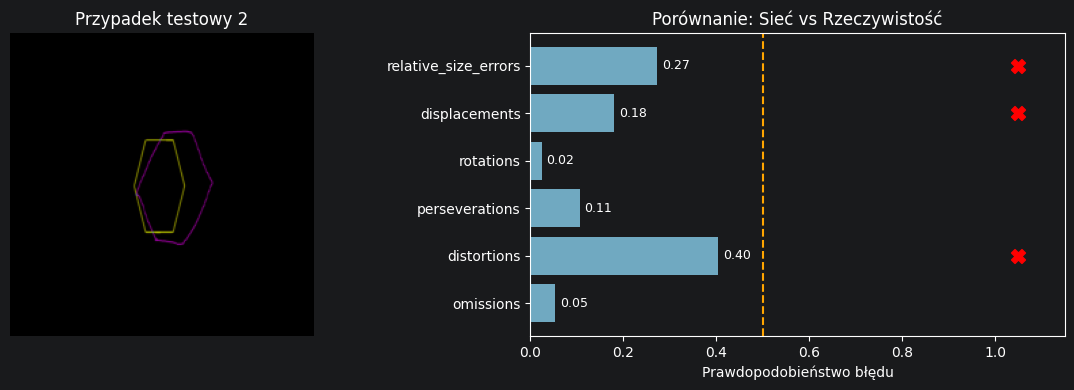

Early stopping triggered at epoch 12
Fold Michal_B finished. Best Val Loss: 0.4297
--- Final Predictions (Best Model) for Michal_B ---


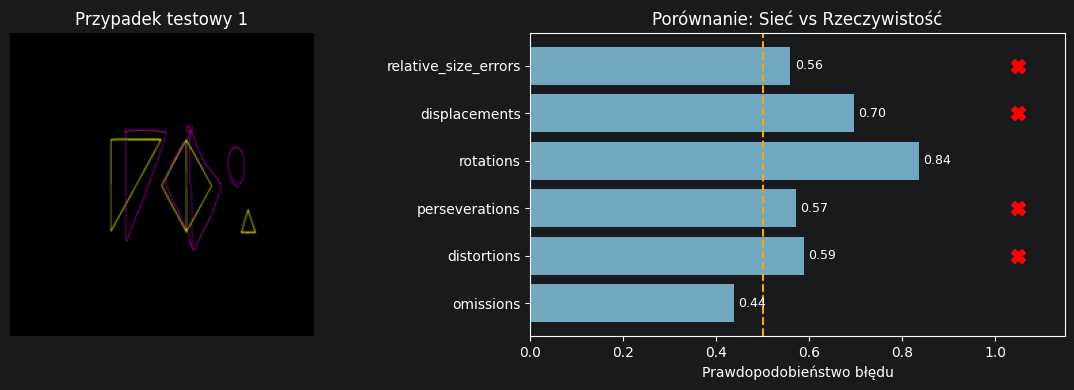

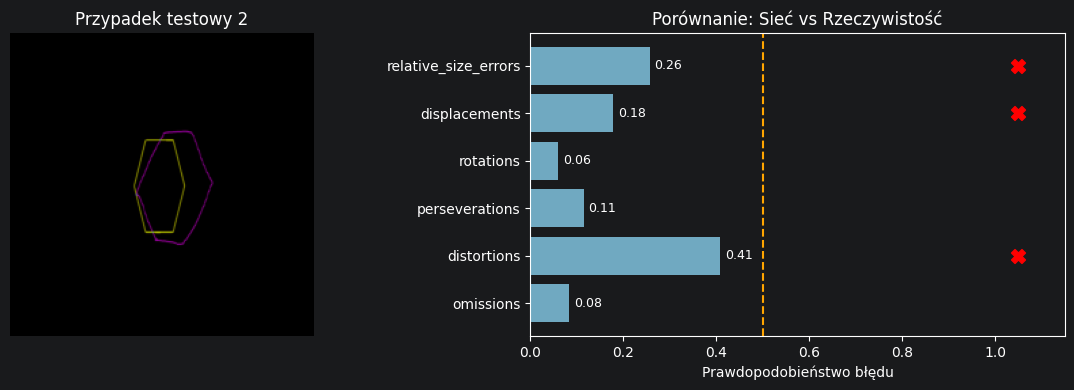

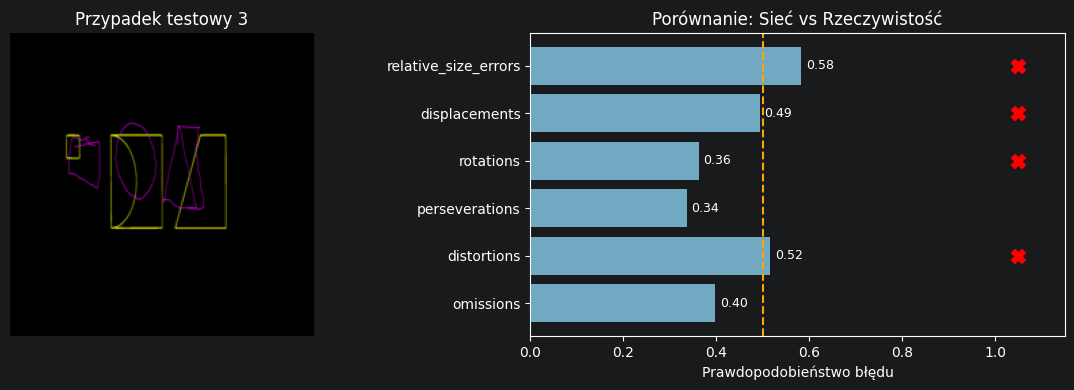

=== Fold: Test Patient = Rita_Kaminska ===
Dynamic pos_weight for this fold: [2.2499993  0.03174603 3.1935475  3.9999986  0.08333333 0.08333333]
BCEWithLogitsLoss does not support label_smoothing. Manual smoothing would be needed.
Epoch 1: New best val_loss: 0.4628
Epoch 3: New best val_loss: 0.4285
Epoch 5: New best val_loss: 0.3943
--- Inspection at Epoch 10 ---


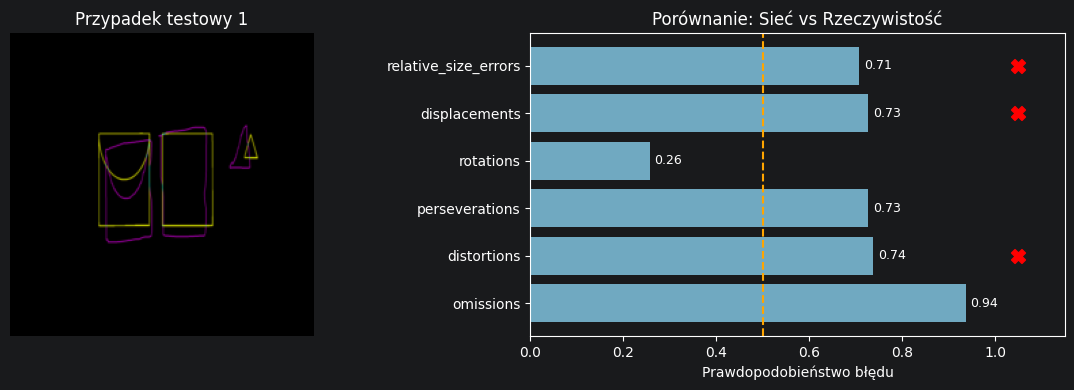

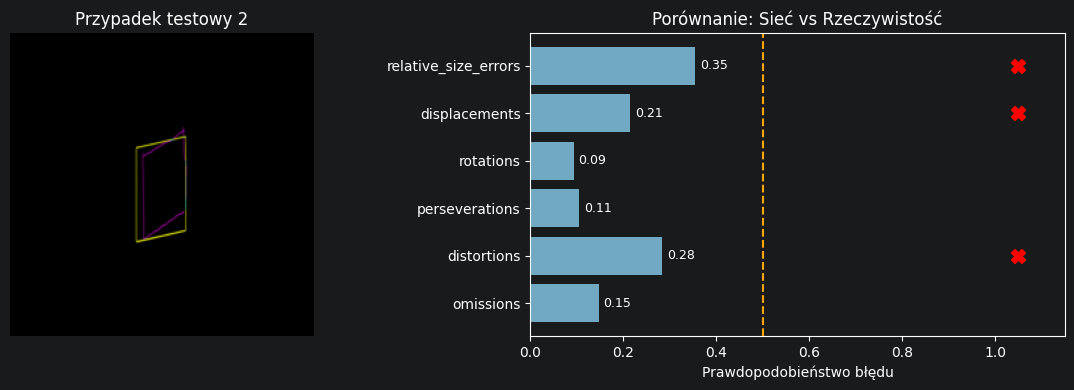

Early stopping triggered at epoch 11
Fold Rita_Kaminska finished. Best Val Loss: 0.3943
--- Final Predictions (Best Model) for Rita_Kaminska ---


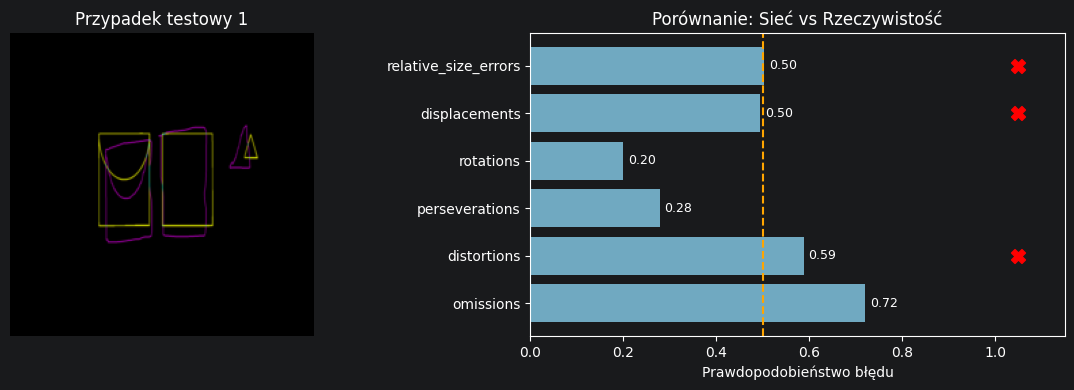

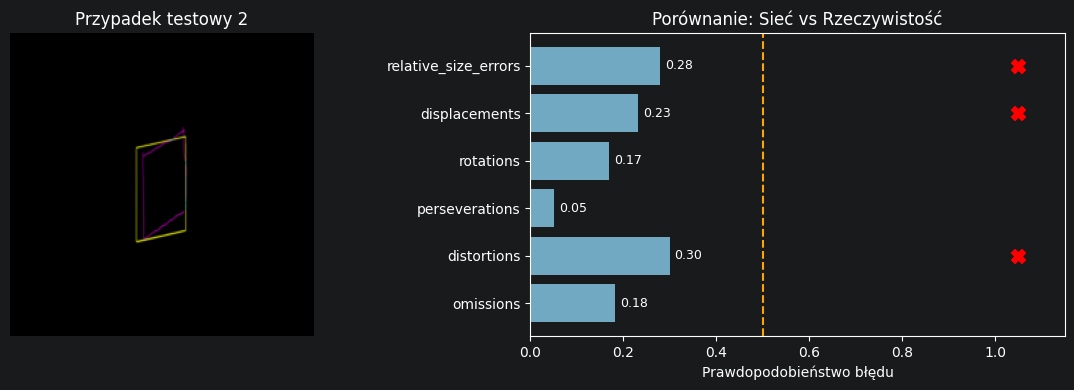

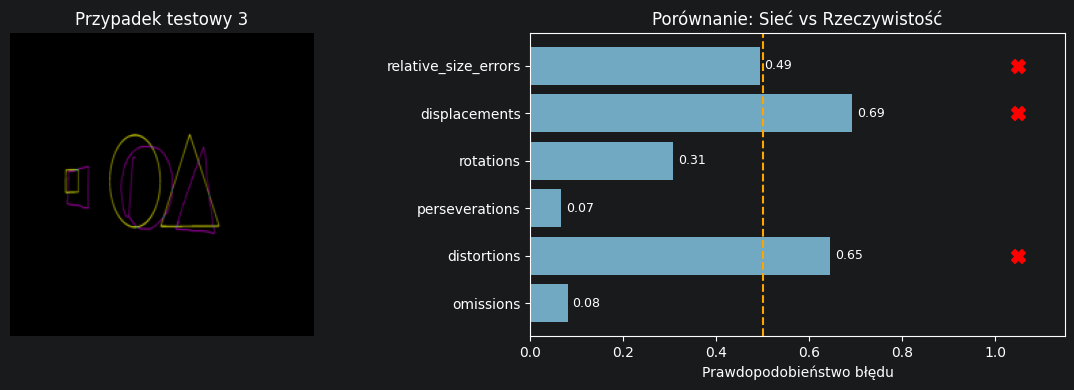

=== Fold: Test Patient = Tymoteusz_K ===
Dynamic pos_weight for this fold: [2.0952375  0.04       3.0624988  3.642856   0.08333333 0.08333333]
BCEWithLogitsLoss does not support label_smoothing. Manual smoothing would be needed.
Epoch 1: New best val_loss: 0.4411
Epoch 2: New best val_loss: 0.4236
Epoch 4: New best val_loss: 0.3870
Epoch 5: New best val_loss: 0.3309
Epoch 8: New best val_loss: 0.3147
--- Inspection at Epoch 10 ---


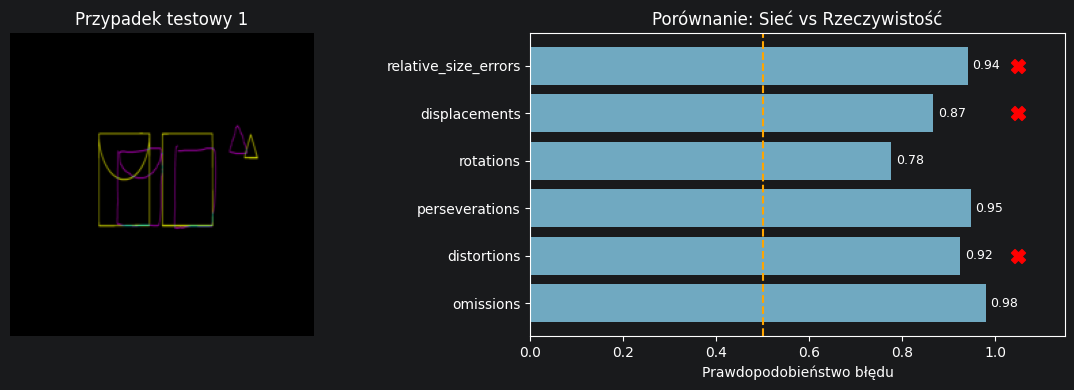

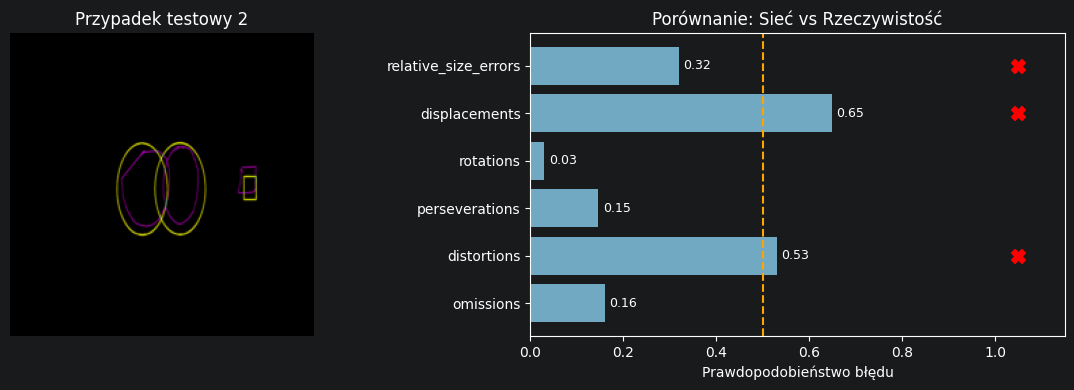

Early stopping triggered at epoch 14
Fold Tymoteusz_K finished. Best Val Loss: 0.3147
--- Final Predictions (Best Model) for Tymoteusz_K ---


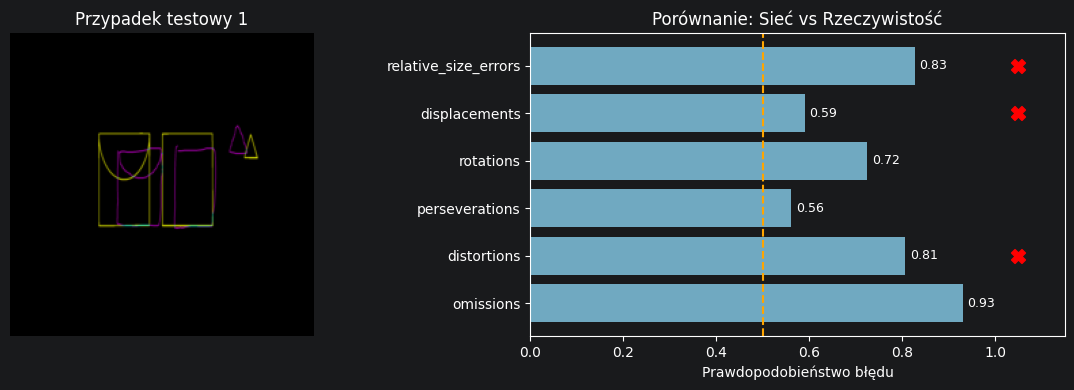

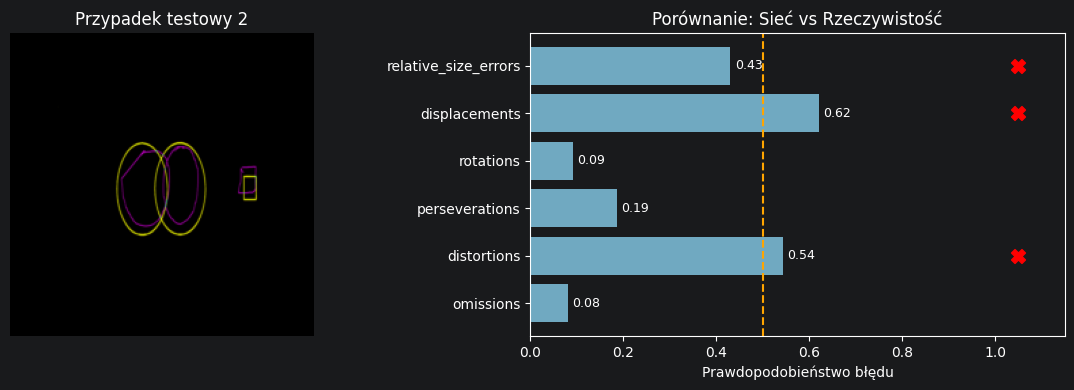

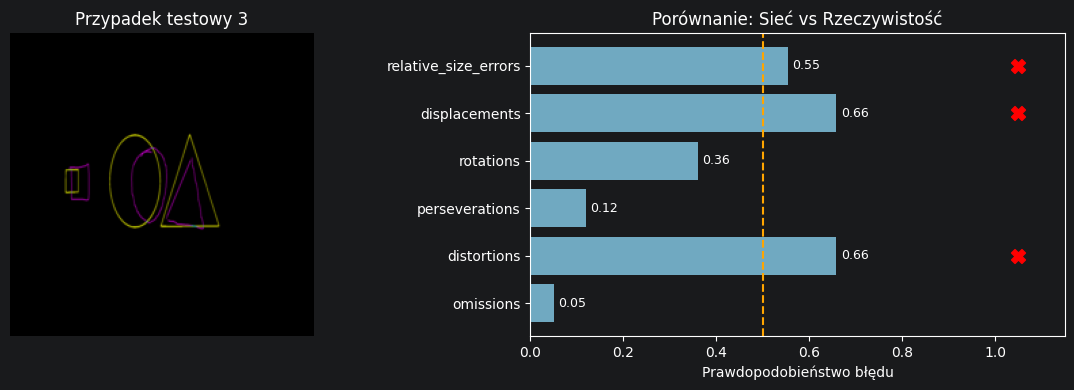

=== Fold: Test Patient = Wojtek_Swiatek ===
Dynamic pos_weight for this fold: [2.3333325  0.04       3.4827576  4.1999984  0.08333333 0.08333333]
BCEWithLogitsLoss does not support label_smoothing. Manual smoothing would be needed.
Epoch 1: New best val_loss: 0.6350
Epoch 4: New best val_loss: 0.5573
Early stopping triggered at epoch 10
Fold Wojtek_Swiatek finished. Best Val Loss: 0.5573
--- Final Predictions (Best Model) for Wojtek_Swiatek ---


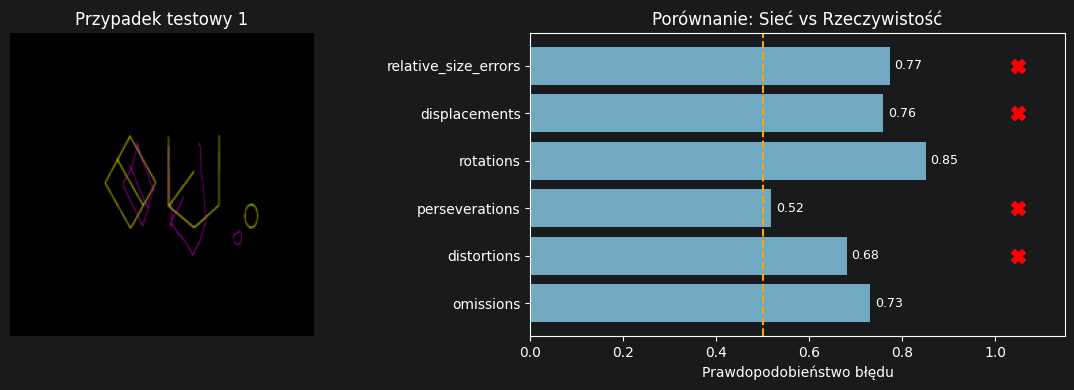

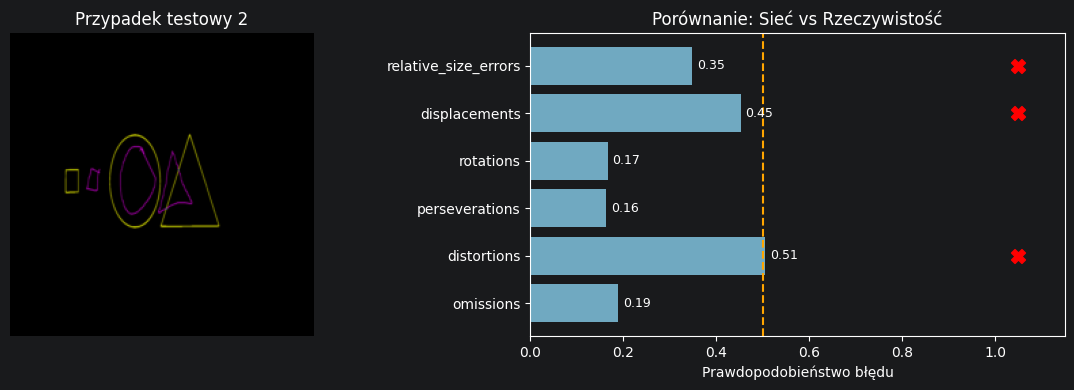

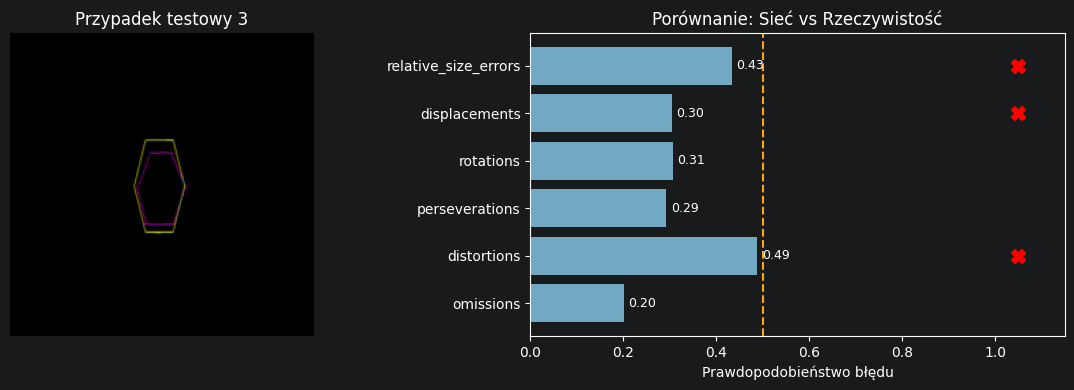

=== Fold: Test Patient = Zosia_B ===
Dynamic pos_weight for this fold: [2.170731   0.04       3.1935475  3.8148134  0.08333333 0.09243697]
BCEWithLogitsLoss does not support label_smoothing. Manual smoothing would be needed.
Epoch 1: New best val_loss: 0.5024
Epoch 2: New best val_loss: 0.4650
Epoch 3: New best val_loss: 0.4527
Epoch 4: New best val_loss: 0.4174
Epoch 7: New best val_loss: 0.4011
--- Inspection at Epoch 10 ---


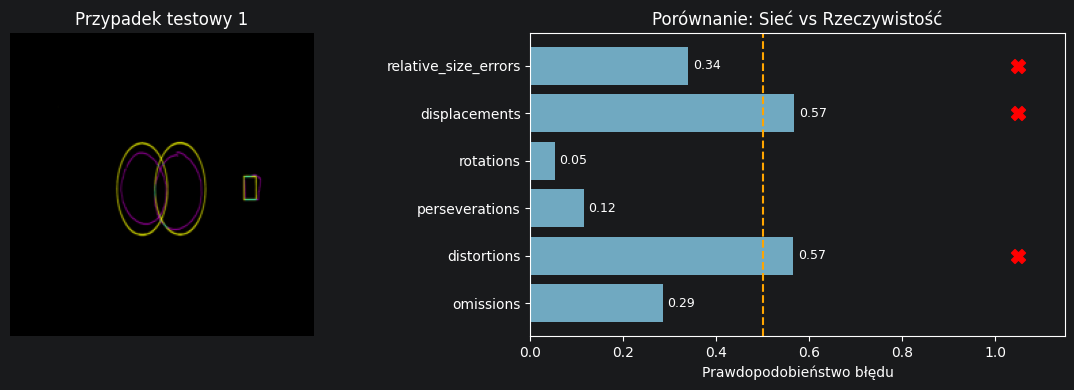

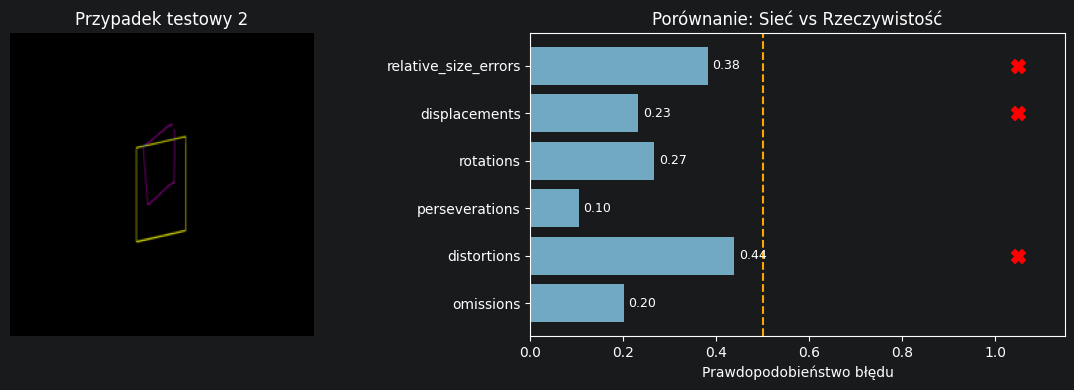

Early stopping triggered at epoch 13
Fold Zosia_B finished. Best Val Loss: 0.4011
--- Final Predictions (Best Model) for Zosia_B ---


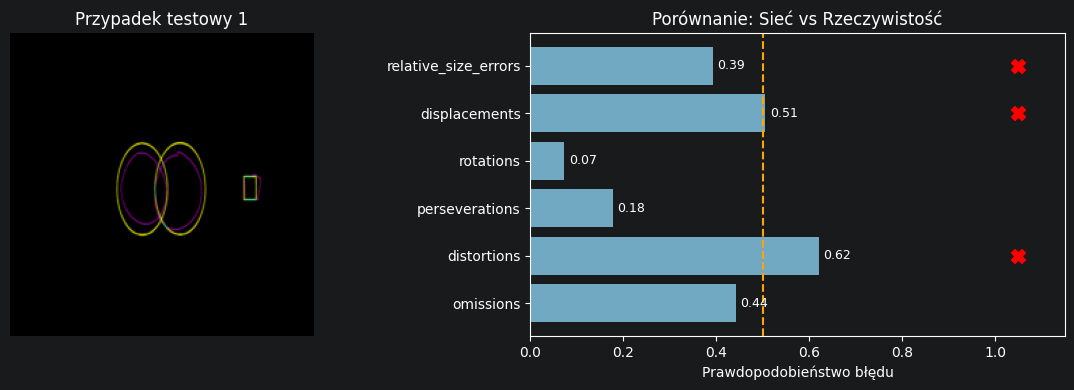

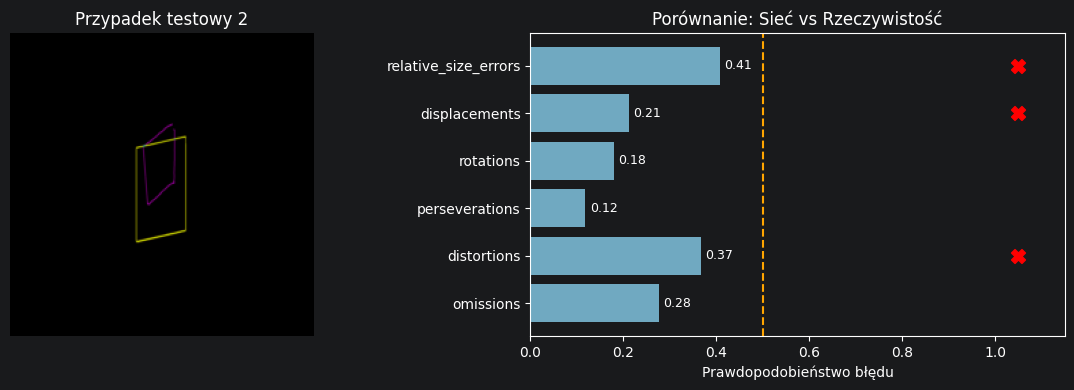

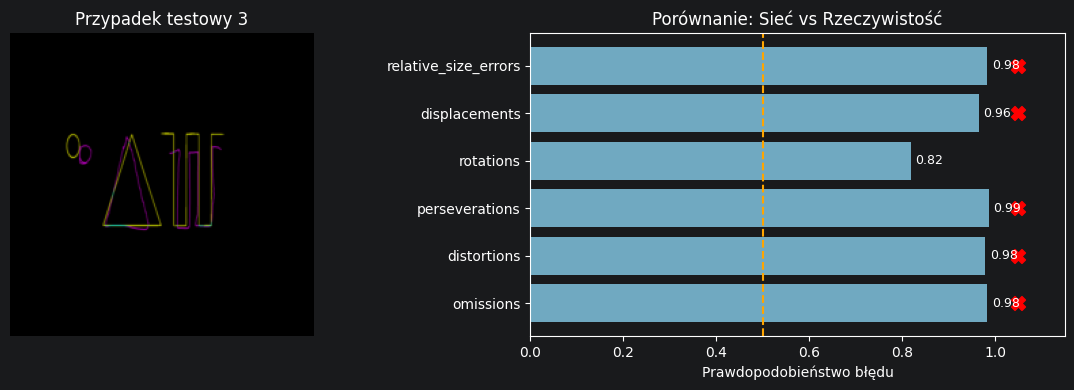

In [72]:
# Uruchomienie poprawionego treningu LOSO
root_data = "../data/processed/3d-input-data"

loso_results = run_loso_training_with_logging(
    root_dir=root_data,
    num_epochs=25,
    inspect_every_n_epochs=10,
    label_smoothing=0.1,
    spatial_dropout=0.2
)

```text
=== RAPORT ŚREDNI ZE WSZYSTKICH FOLDÓW LOSO ===
Liczba uwzględnionych foldów/pacjentów: 14
Maksymalna liczba epok treningu: 17

Epoka  | Train Loss | Val Loss   | Macro F1 | Micro F1
-------------------------------------------------------
1      | 0.5330     | 0.5596     | 0.6471   | 0.7398  
2      | 0.4436     | 0.5228     | 0.6659   | 0.7523  
3      | 0.4054     | 0.5223     | 0.6717   | 0.7484  
4      | 0.3825     | 0.4999     | 0.6742   | 0.7571  
5      | 0.3573     | 0.4853     | 0.6706   | 0.7591  
6      | 0.3349     | 0.5177     | 0.6447   | 0.7396  
7      | 0.3156     | 0.5306     | 0.6384   | 0.7233  
8      | 0.2920     | 0.5419     | 0.6300   | 0.7190  
9      | 0.2810     | 0.5892     | 0.6229   | 0.7246  
10     | 0.2679     | 0.5529     | 0.6449   | 0.7296  
11     | 0.2525     | 0.5938     | 0.6223   | 0.7233  
12     | 0.2512     | 0.5904     | 0.6264   | 0.7218  
13     | 0.2485     | 0.5963     | 0.6184   | 0.7187  
14     | 0.2466     | 0.5920     | 0.6

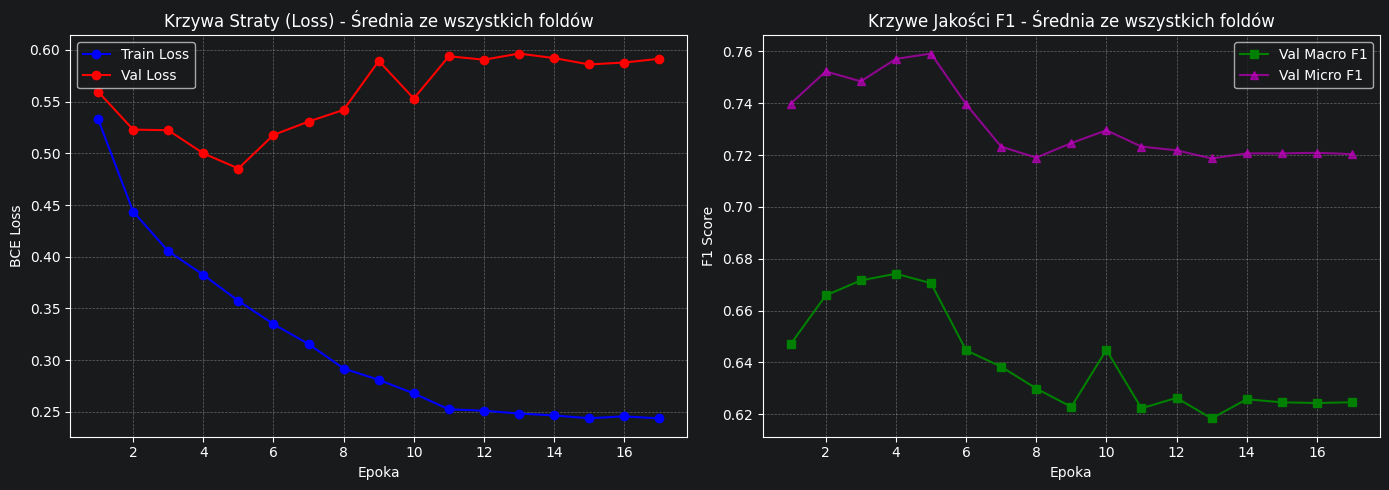

In [81]:
plot_loso_history(loso_history=loso_results)